In [42]:
import pickle
# 得到生成数据
with open('result.pkl', 'rb') as f:
    loaded_result = pickle.load(f)



In [43]:
import pickle
import numpy as np
with open('test.pkl', 'rb') as f:
    loaded_test = pickle.load(f)

# print(loaded_test['param'] * (loaded_test['ignore_mask']))
test_boundary =  loaded_test['param'] * (loaded_test['ignore_mask'] == False)
test_box =  loaded_test['param'] * (loaded_test['ignore_mask'])

In [44]:
# 画图处理
box = []
for i in range(test_box.shape[0]):
    matrix = test_box[i]
    _box_ = []
    non_zero_rows = matrix[~np.all(matrix == 0, axis=1)]
    for _ in non_zero_rows:
        _box_.append(_.reshape(-1, 2))
    box.append(_box_)

boundary = []
for i in range(test_boundary.shape[0]):
    matrix = test_boundary[i]
    _box_ = []
    non_zero_rows = matrix[~np.all(matrix == 0, axis=1)]
    for _ in non_zero_rows:
        _box_.append(_.reshape(-1, 2))
    boundary.append(_box_)

box_ = []
for i in range(test_box.shape[0]):
    matrix = loaded_result[i]
    _box_ = []
    non_zero_rows = matrix[~np.all(matrix == 0, axis=1)]
    for _ in non_zero_rows:
        _box_.append(_.reshape(-1, 2))
    box_.append(_box_)


C:\Users\NaClCode\AppData\Local\Temp\ipykernel_18468\2330309507.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


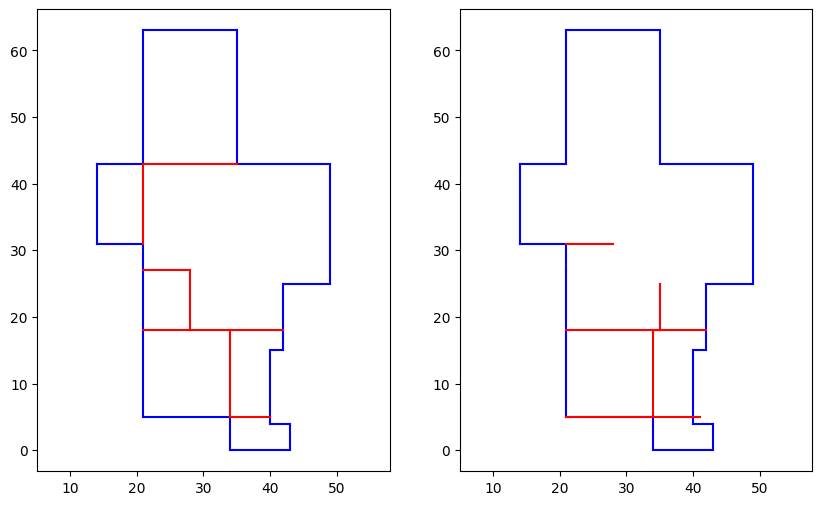

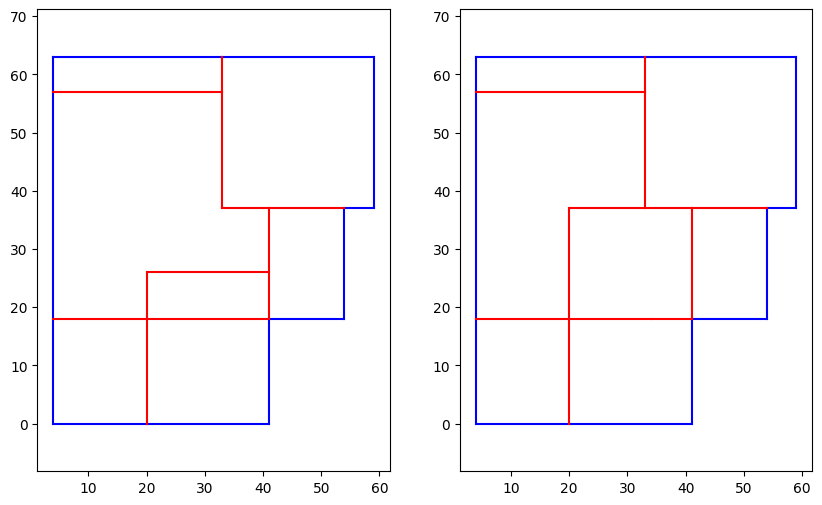

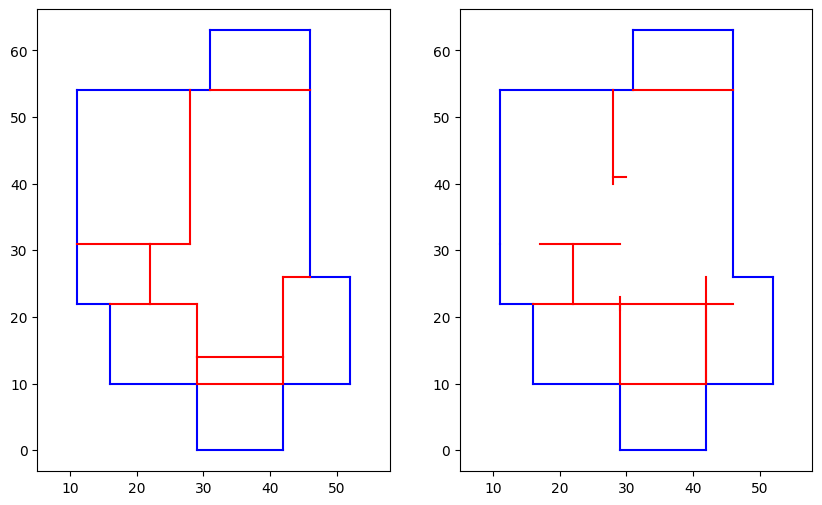

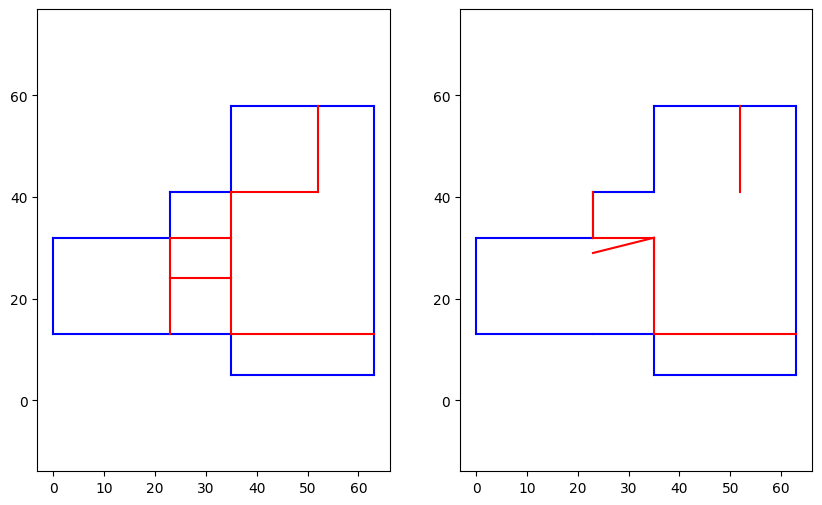

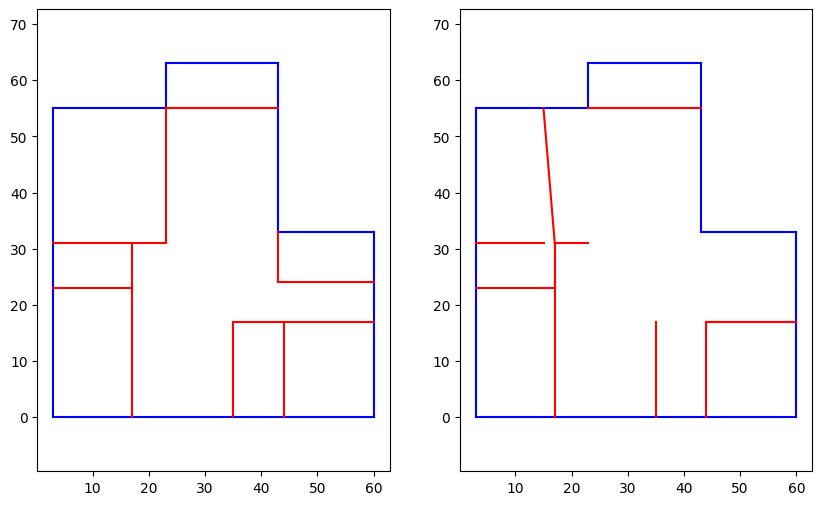

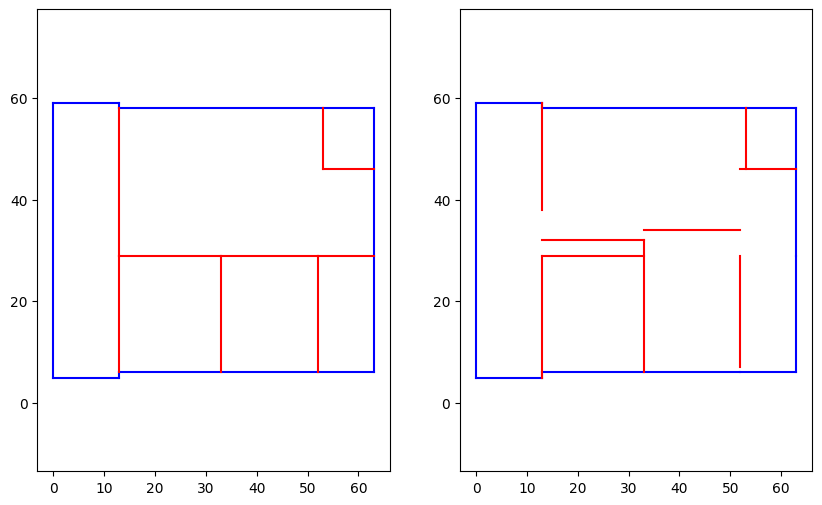

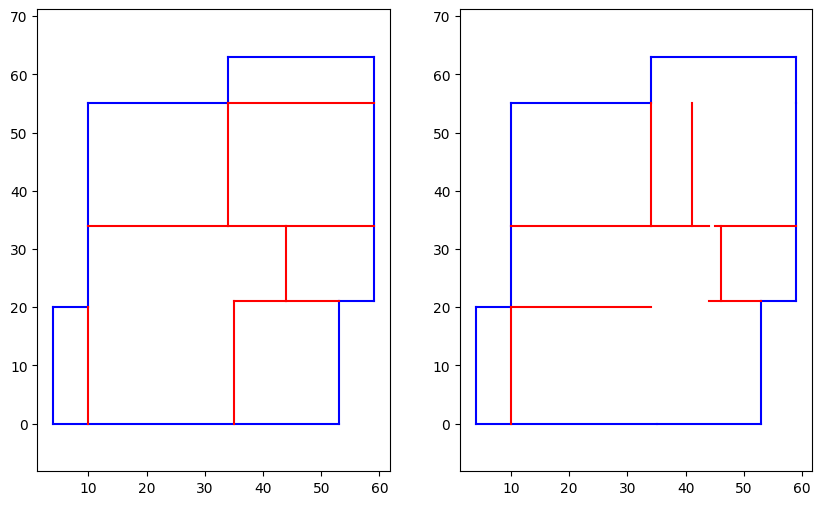

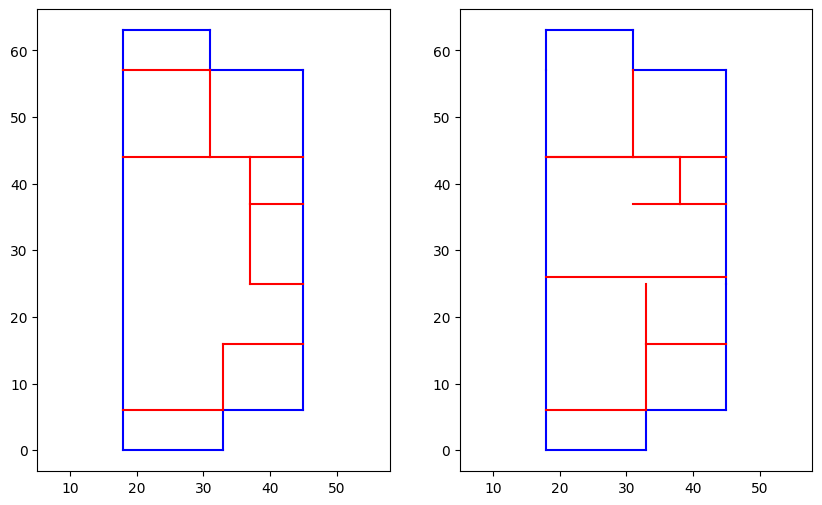

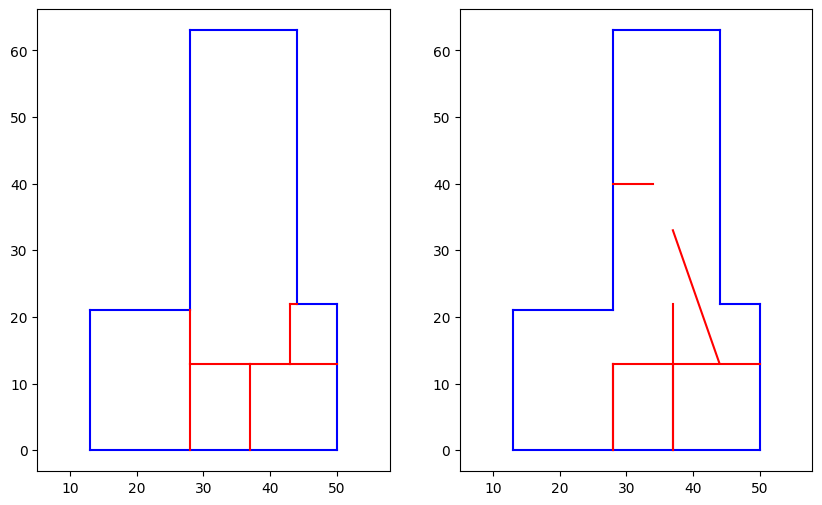

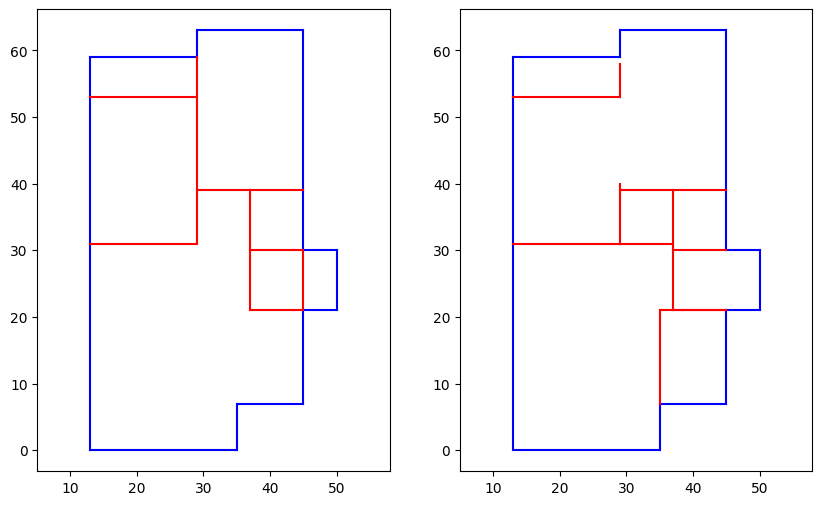

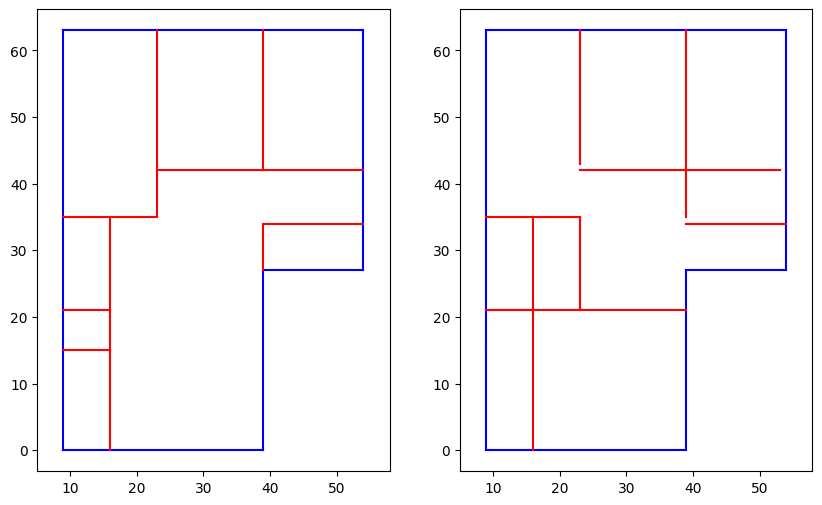

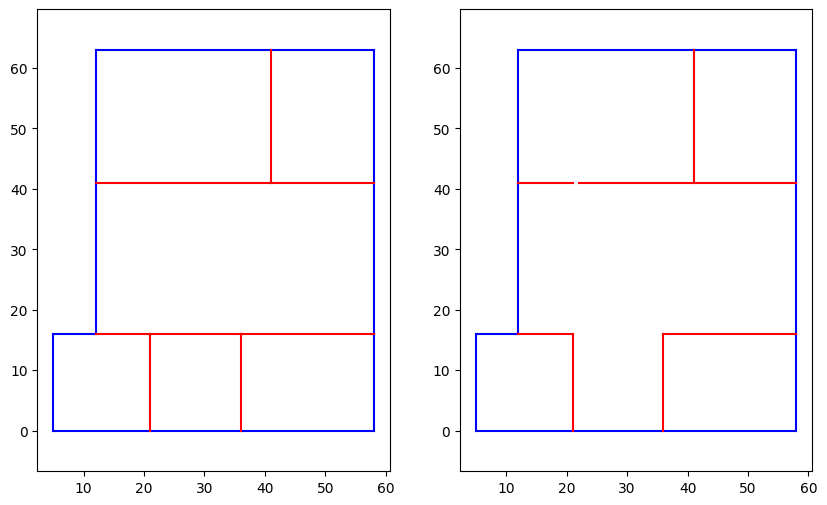

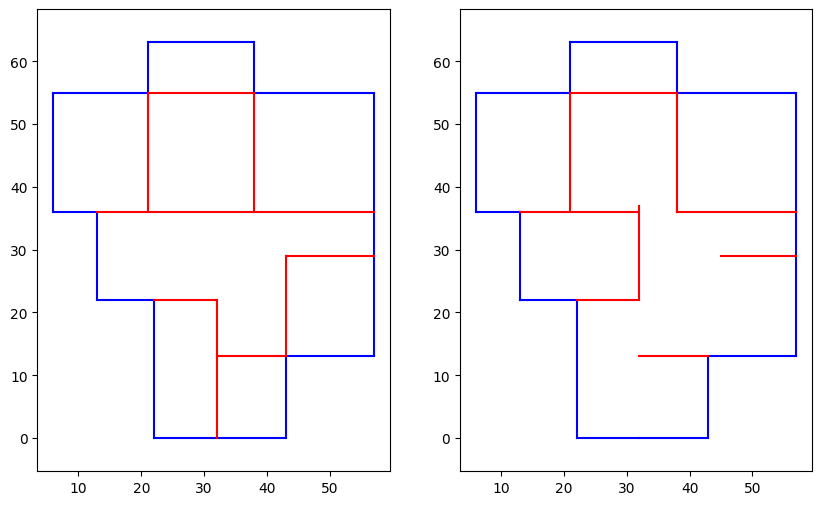

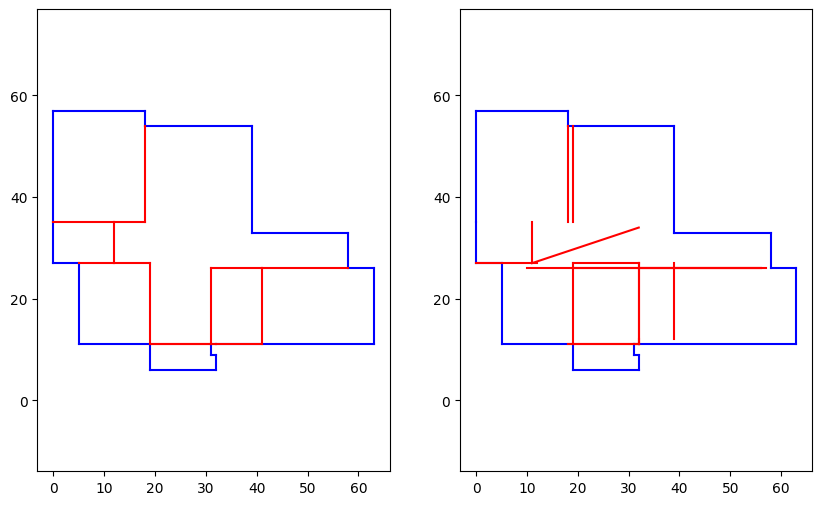

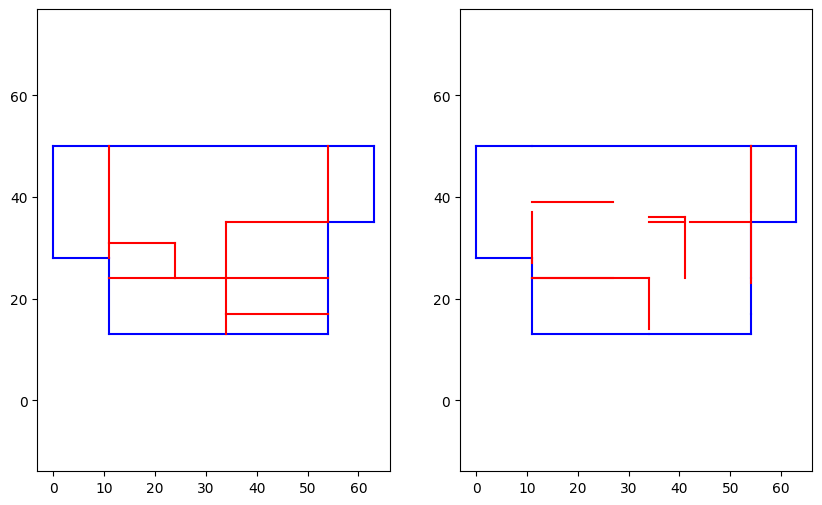

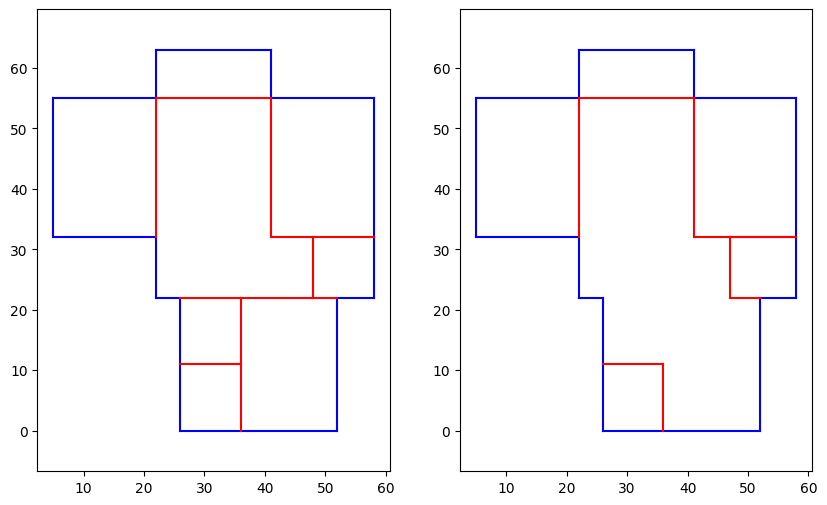

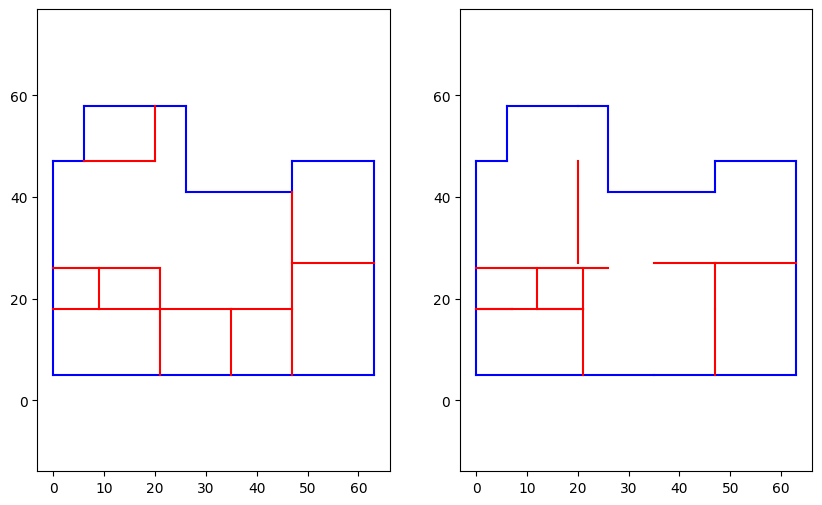

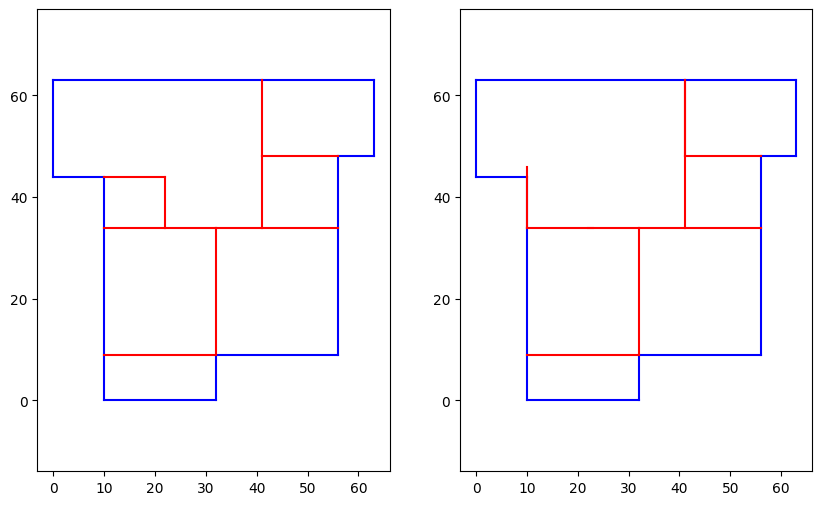

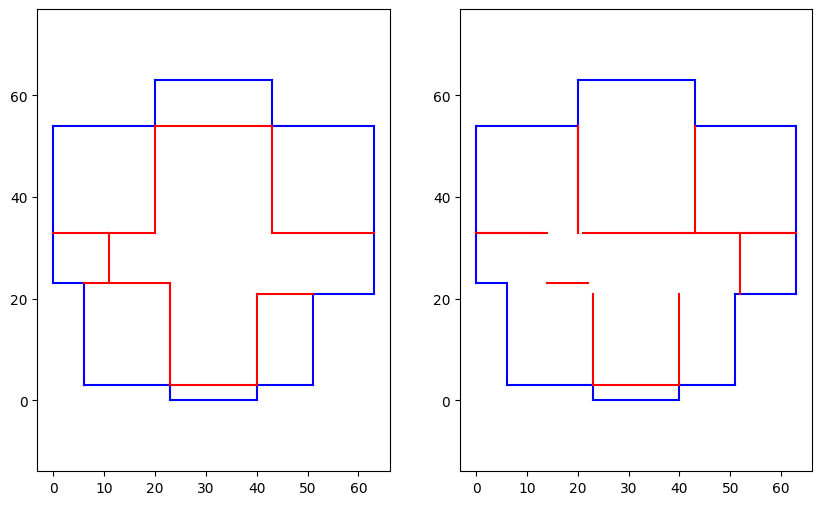

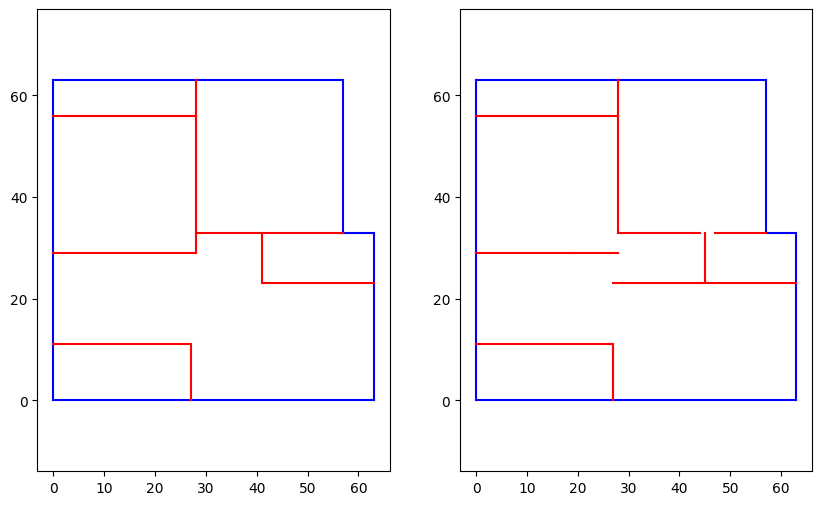

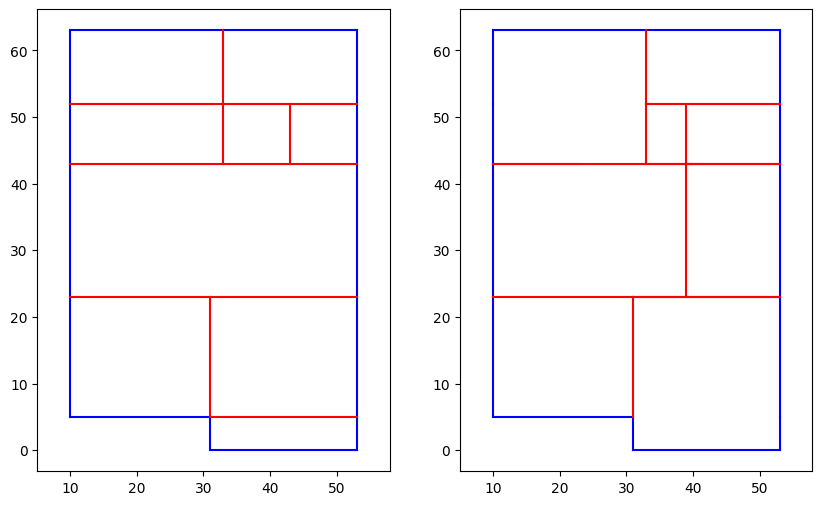

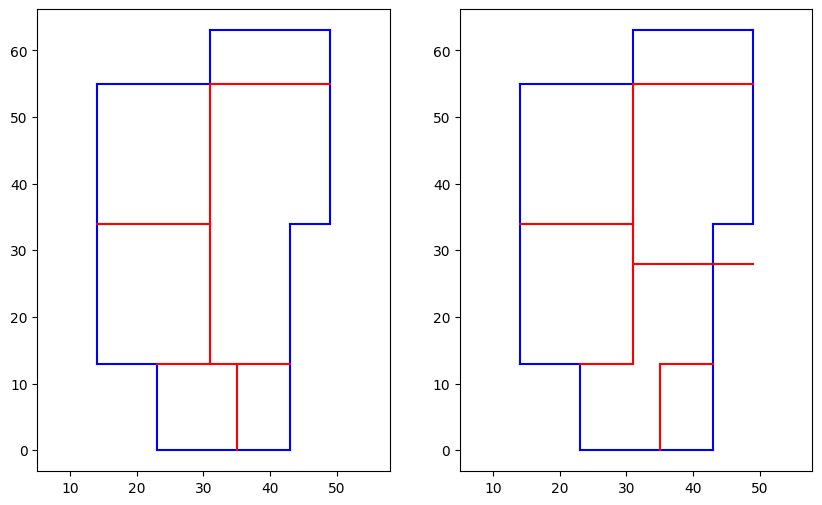

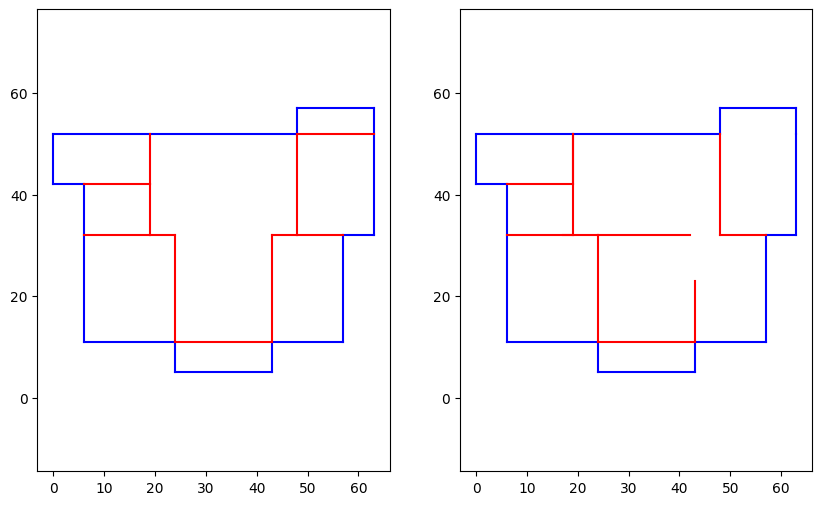

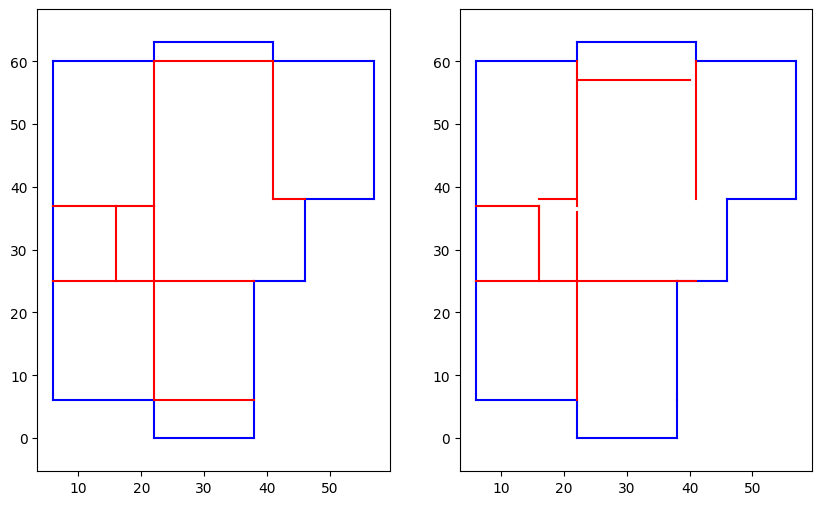

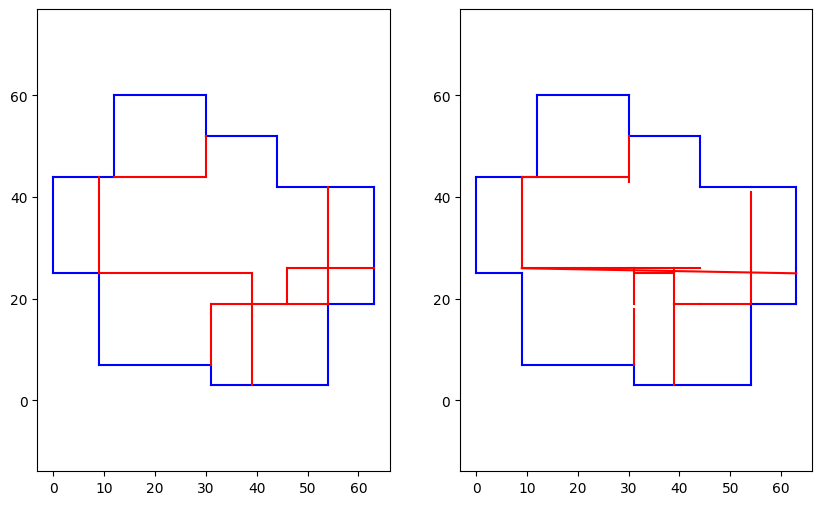

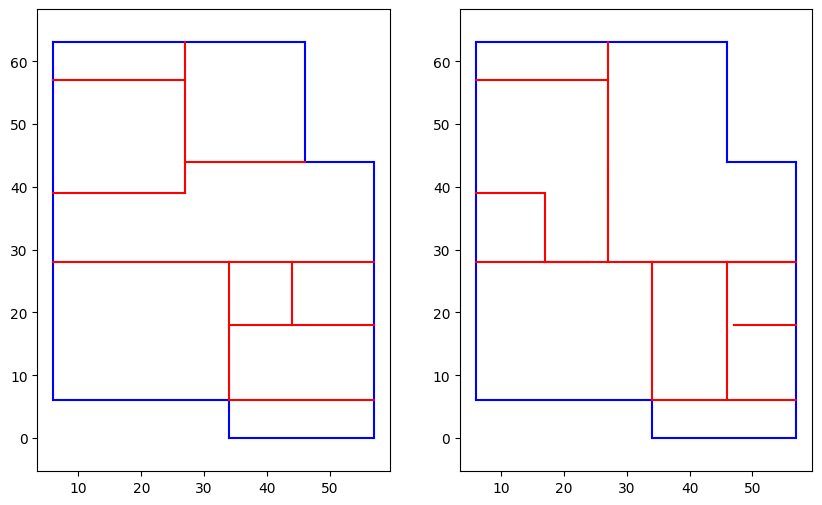

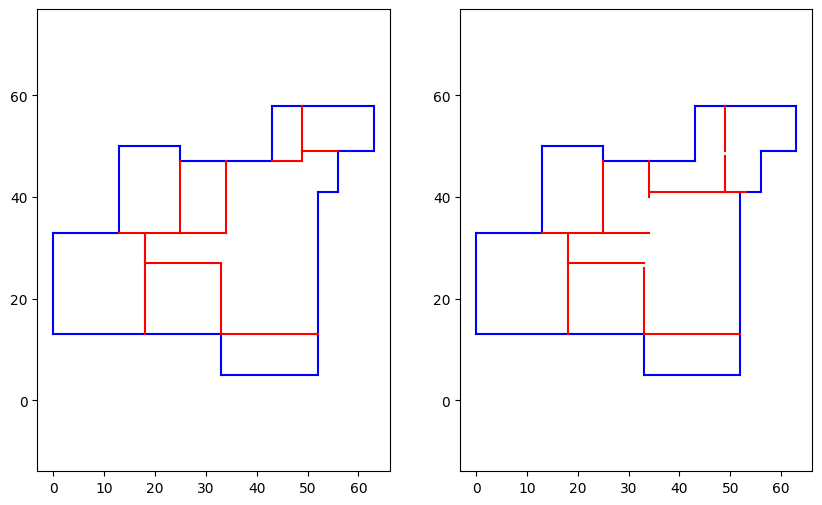

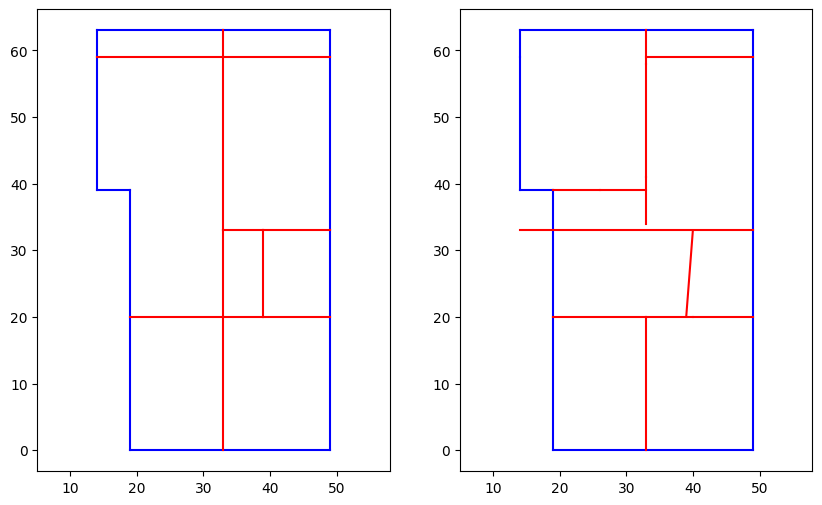

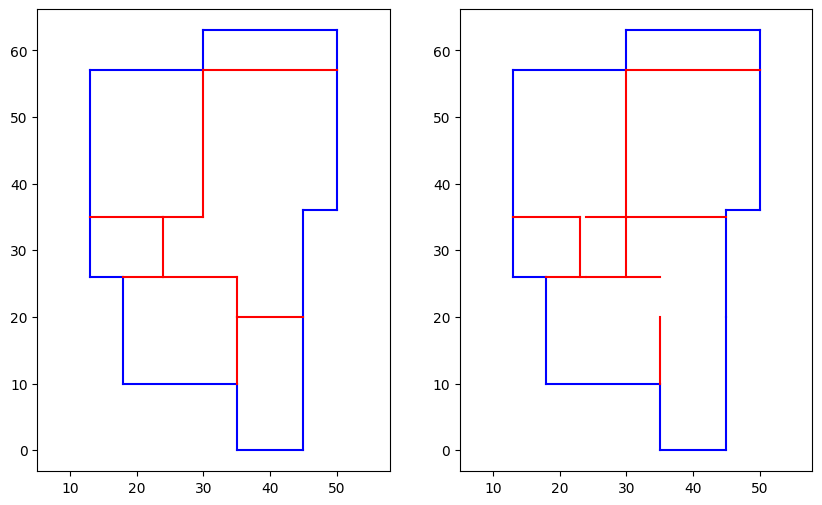

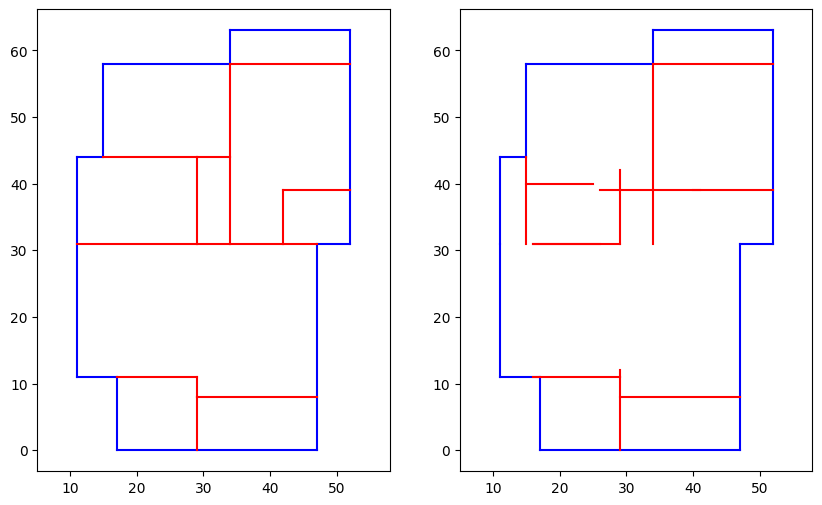

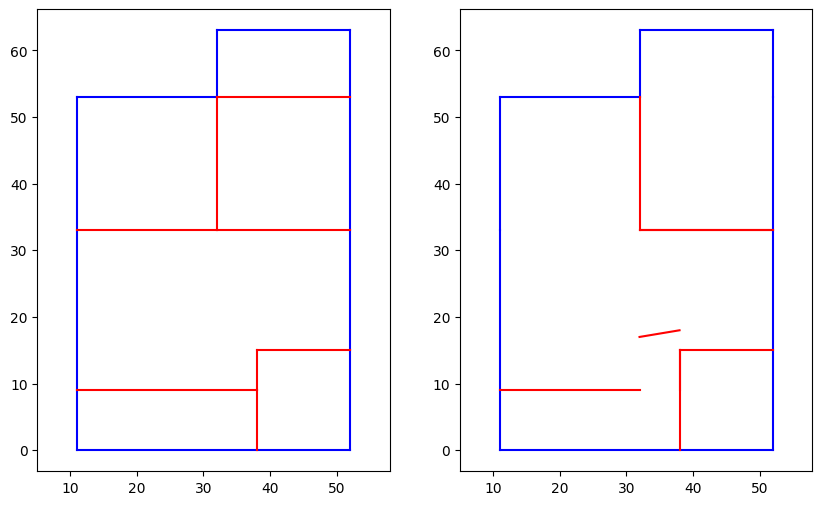

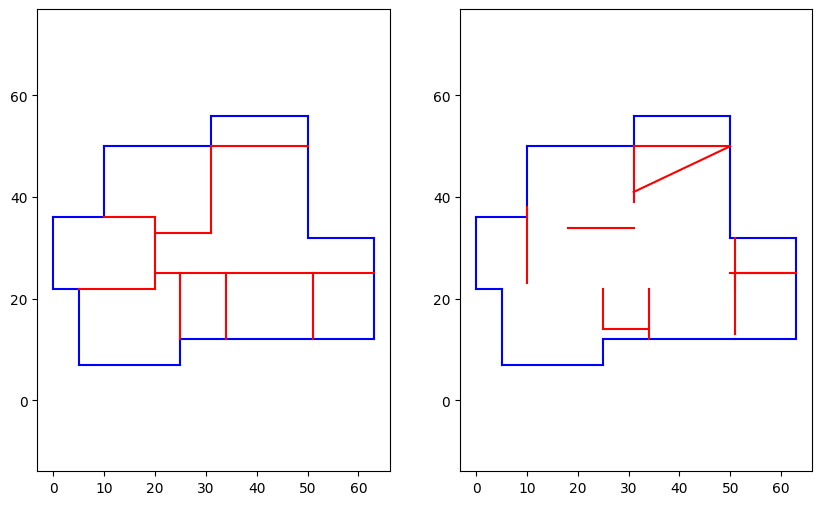

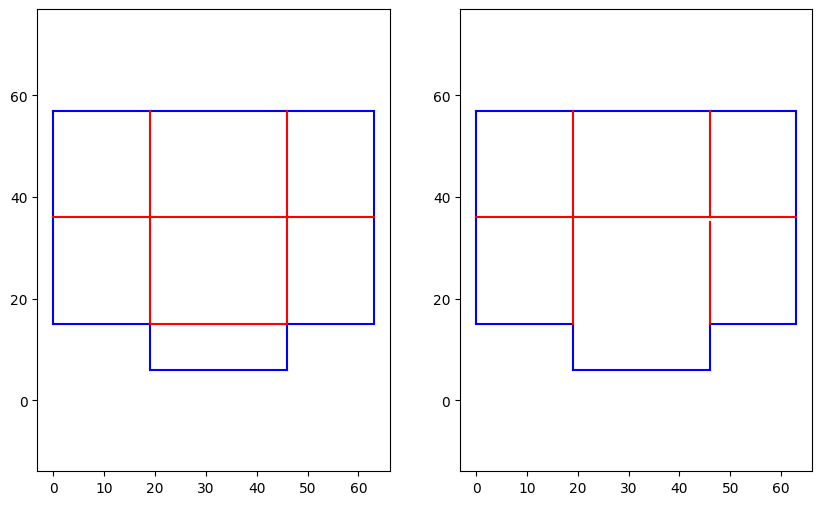

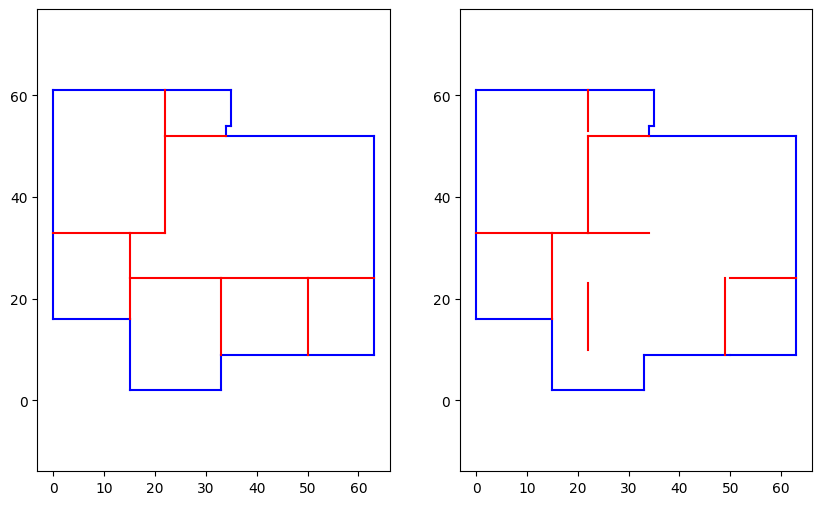

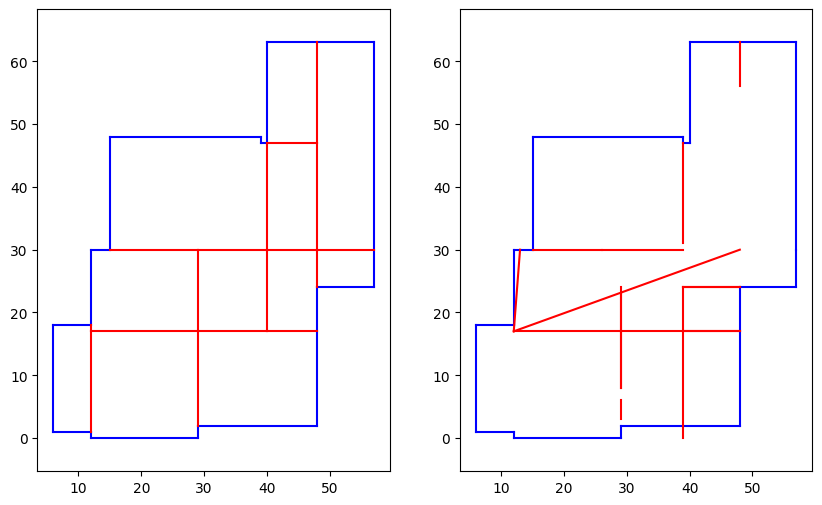

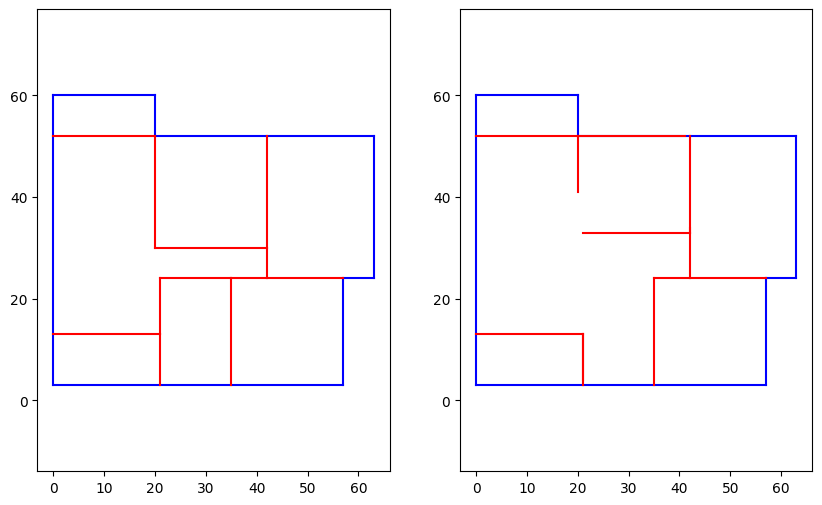

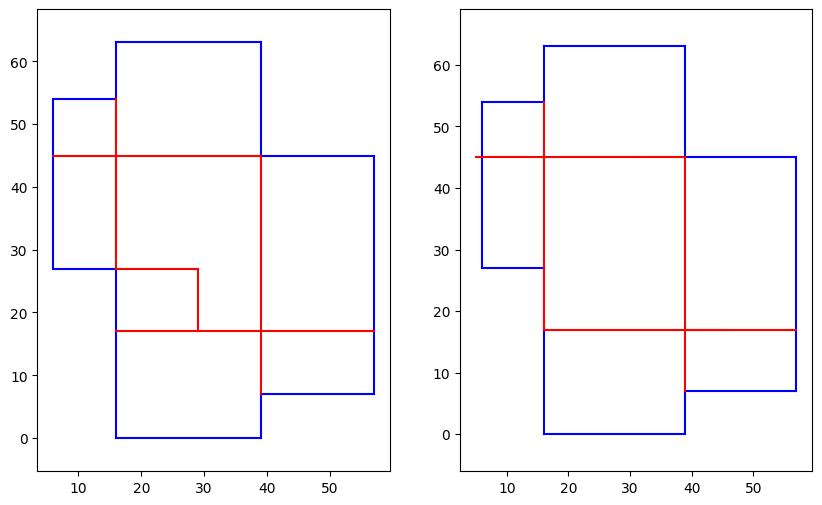

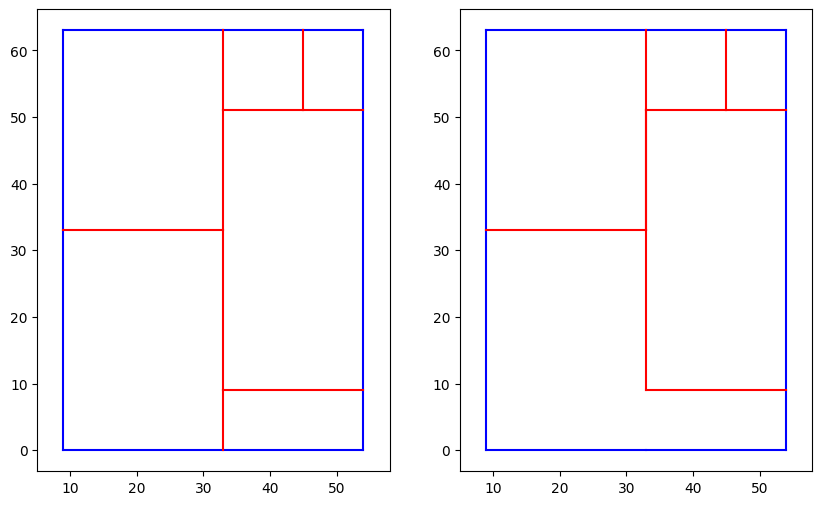

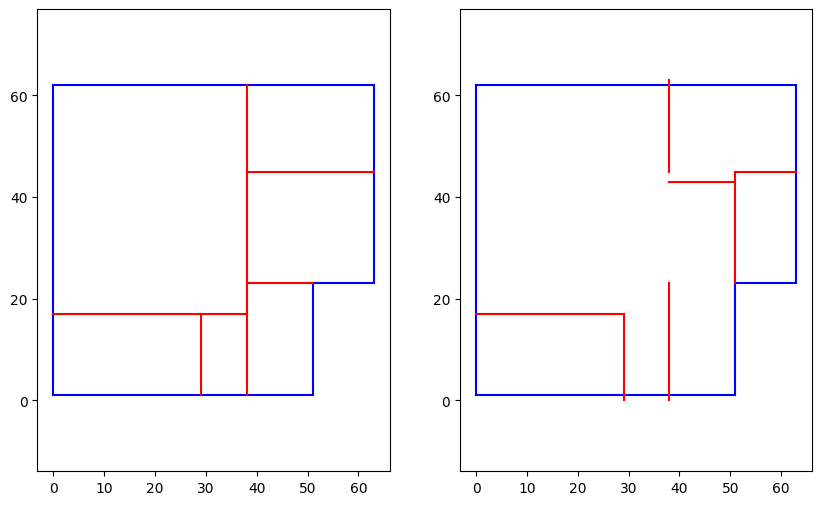

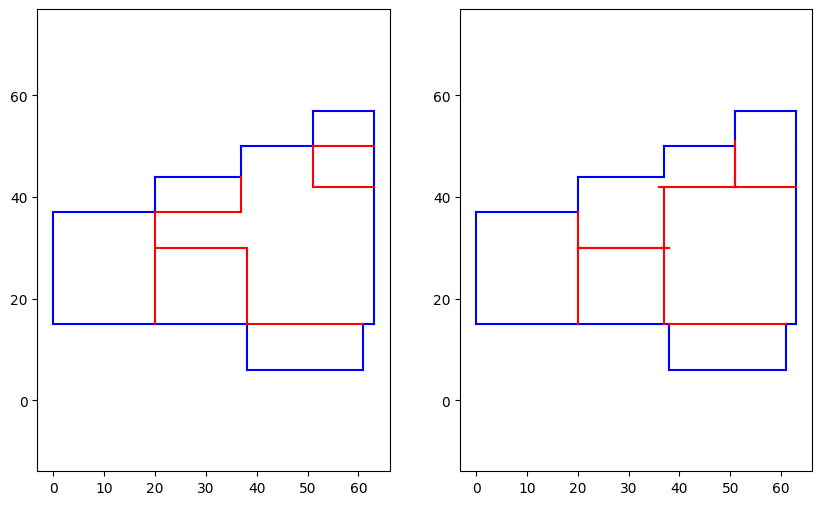

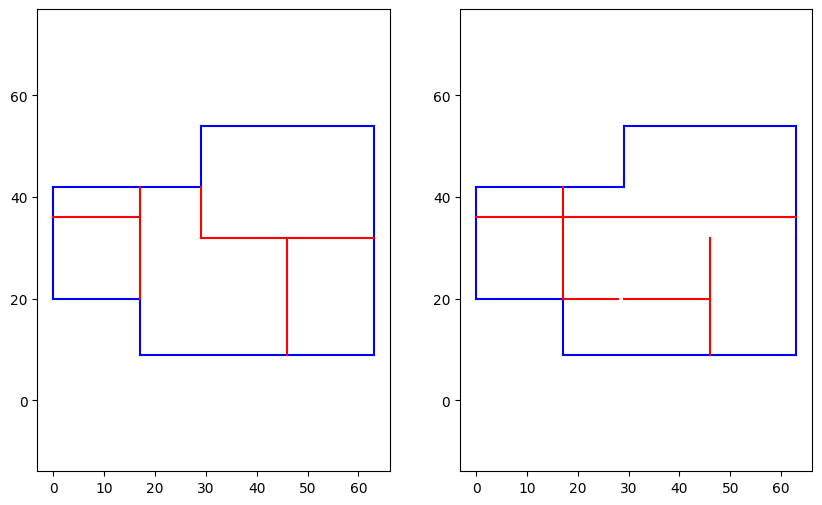

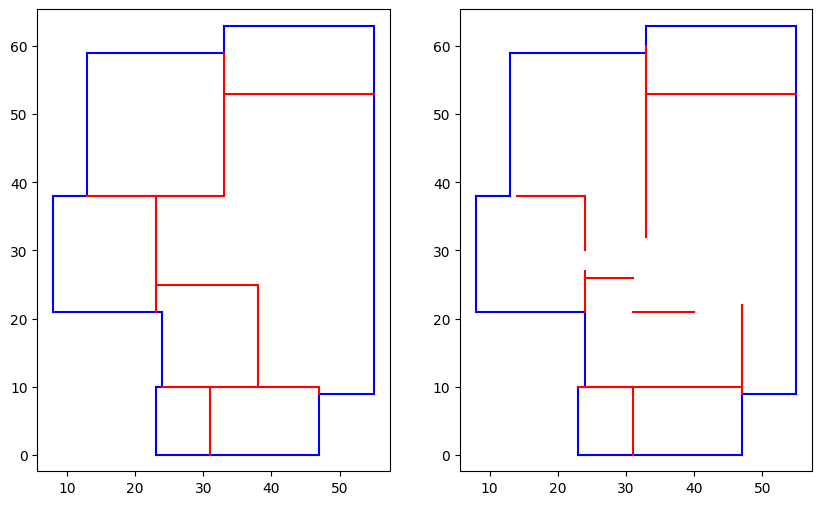

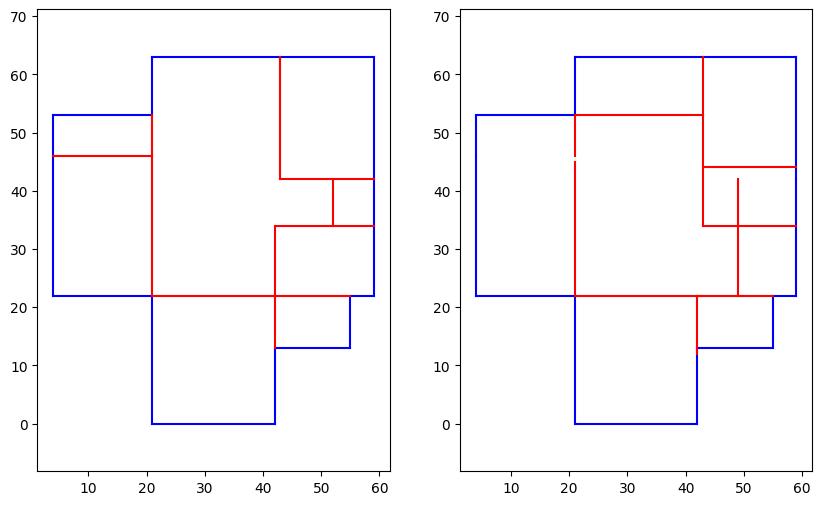

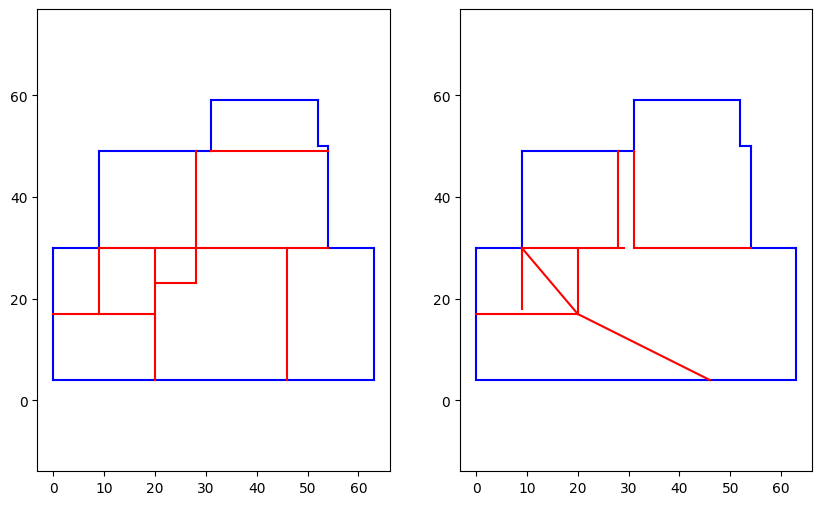

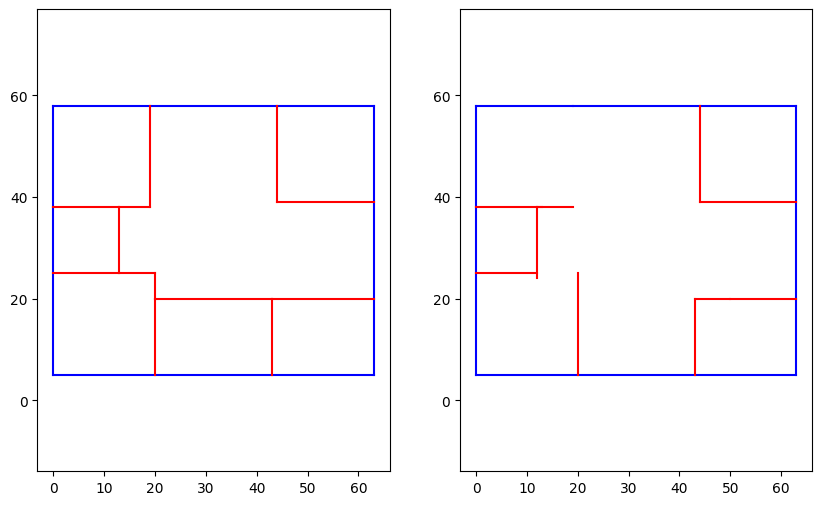

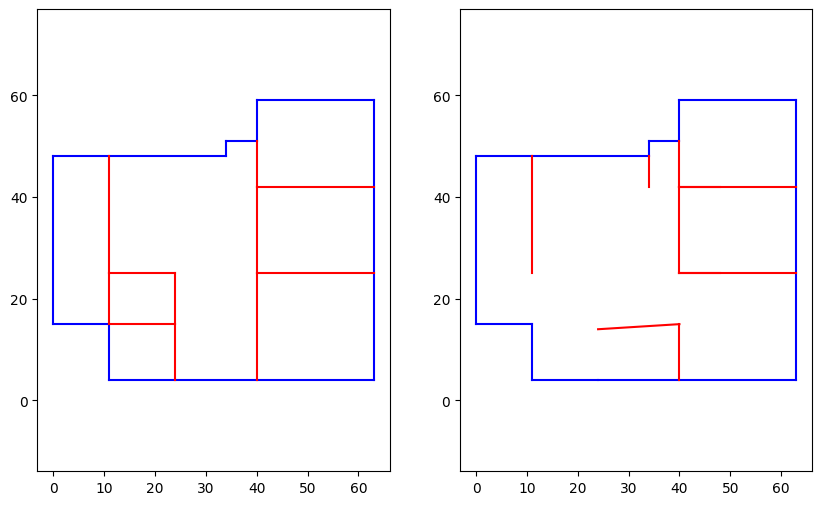

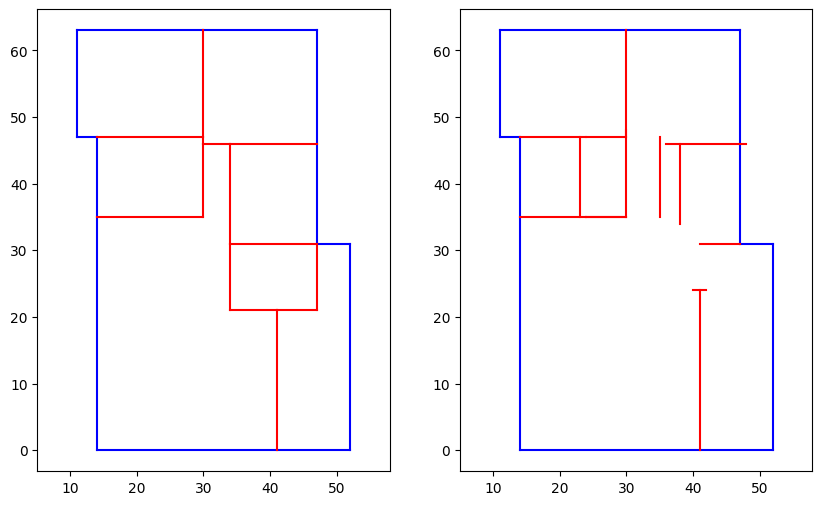

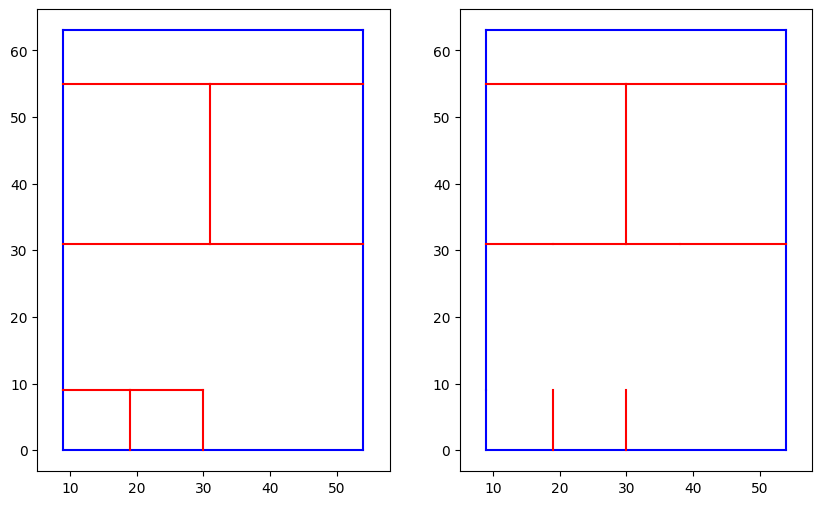

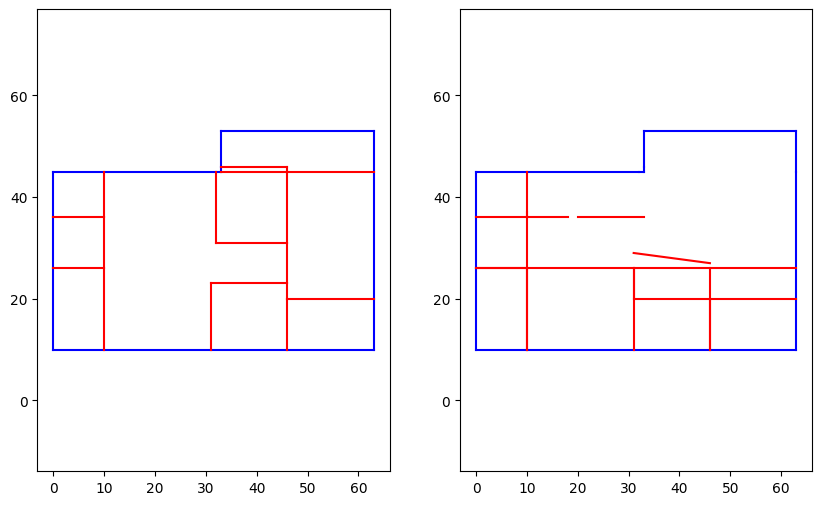

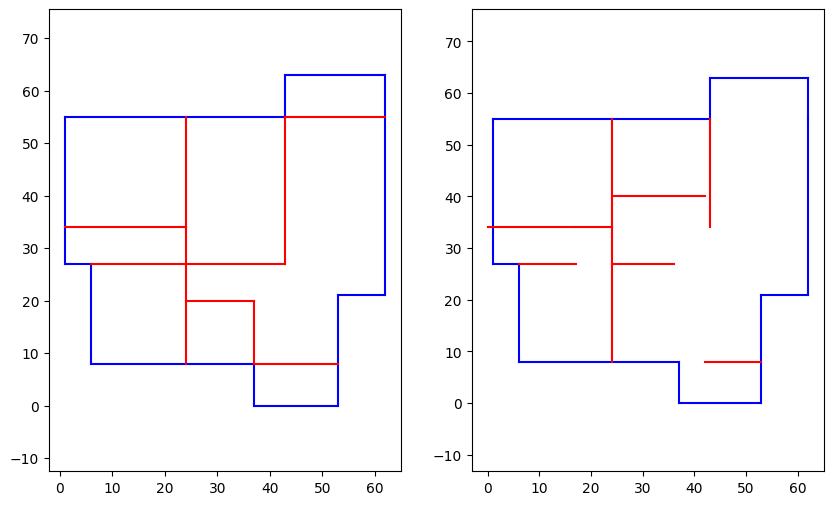

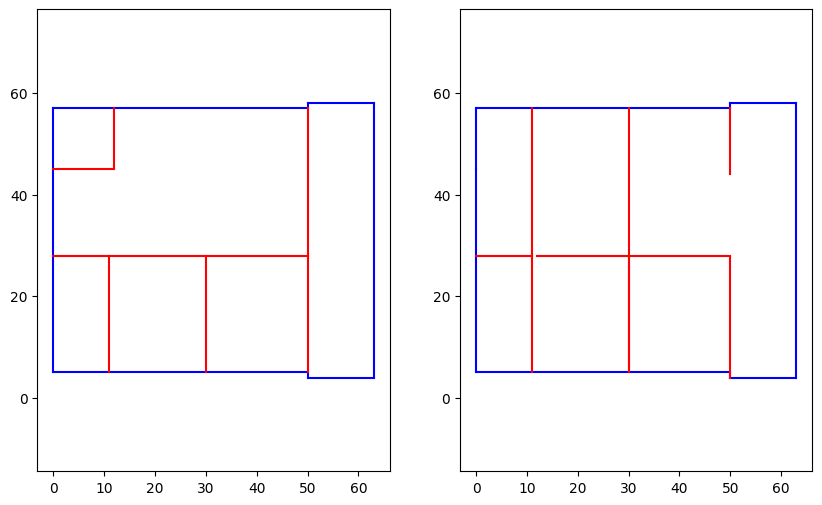

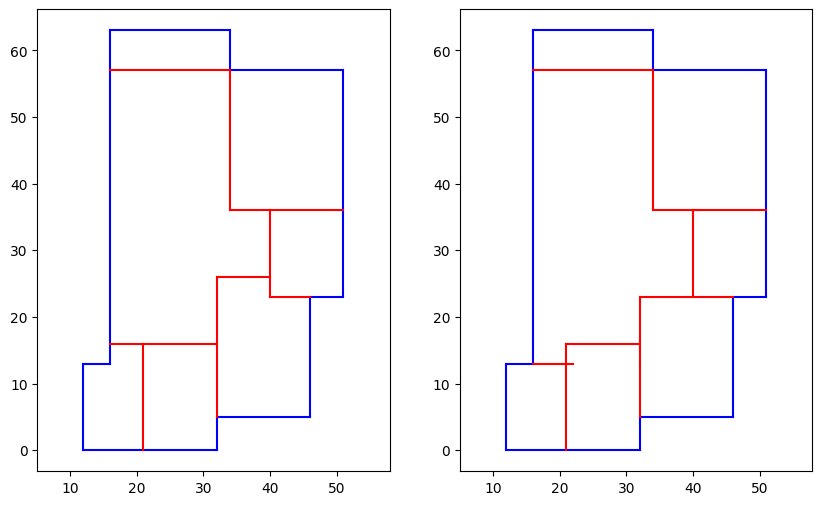

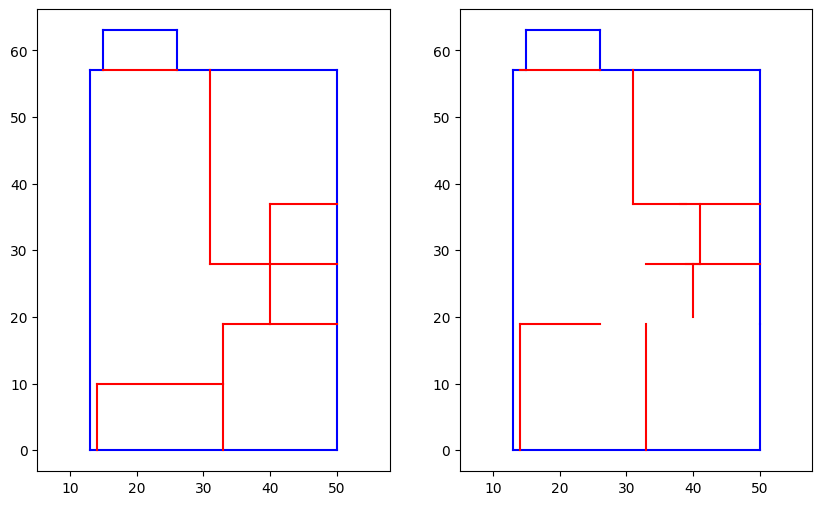

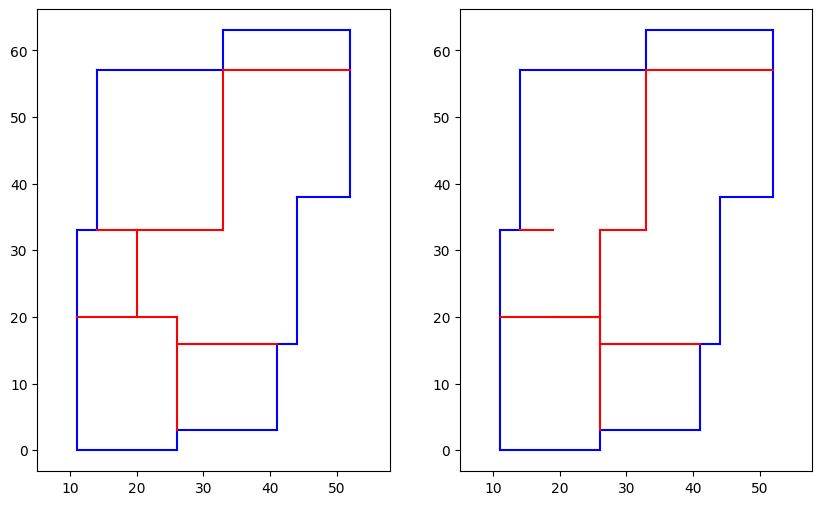

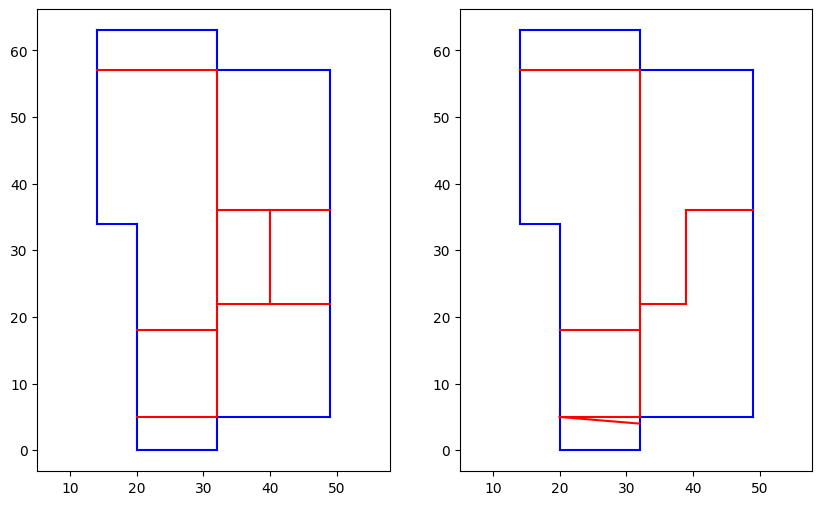

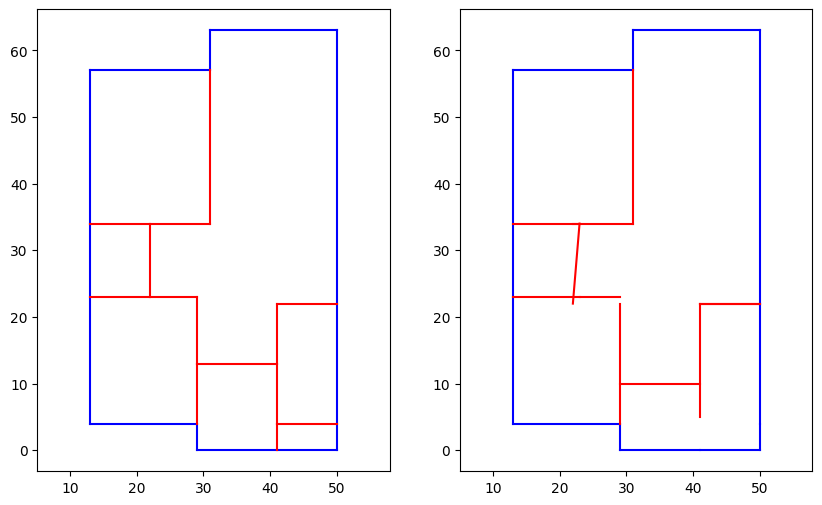

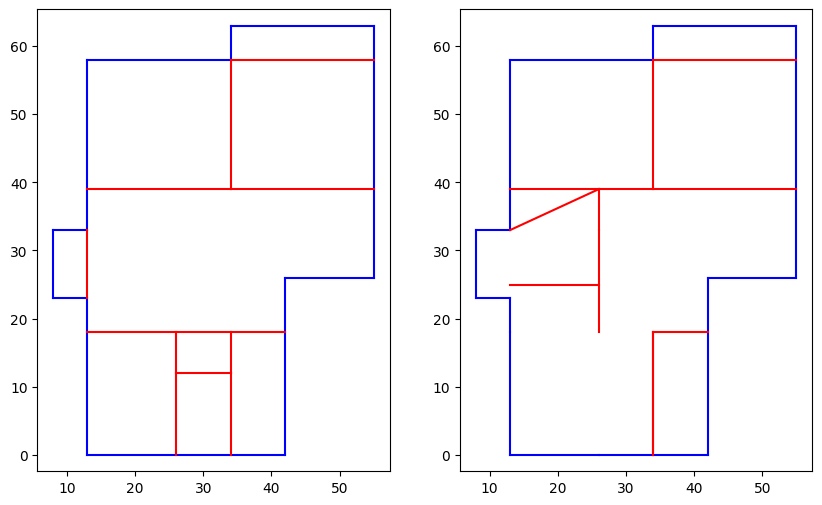

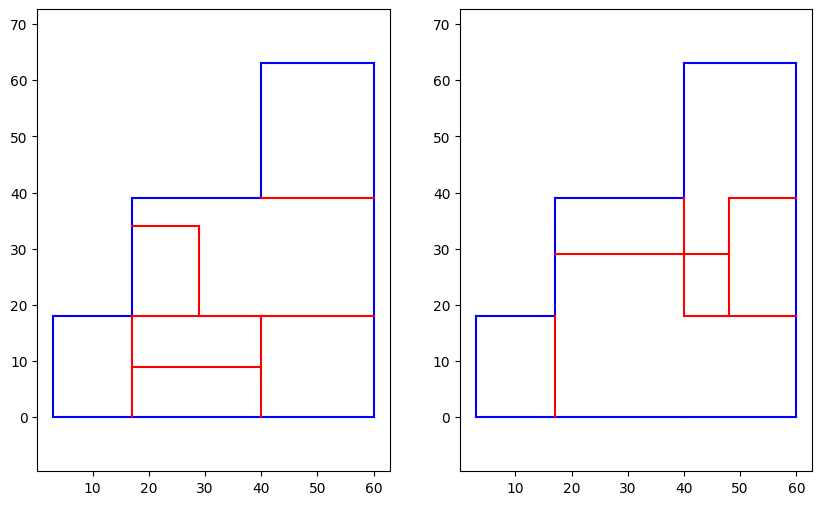

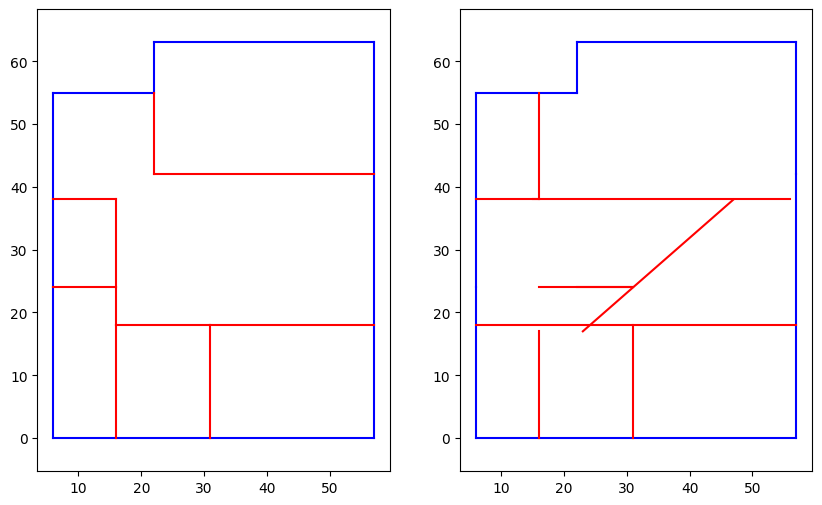

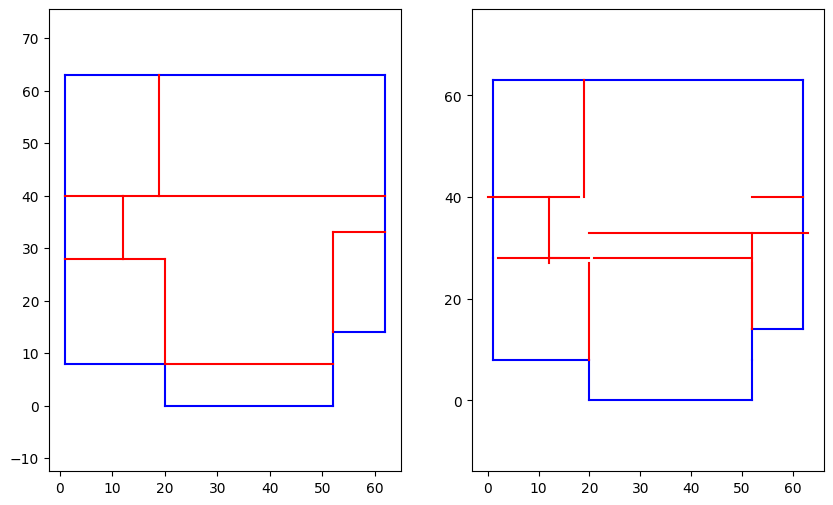

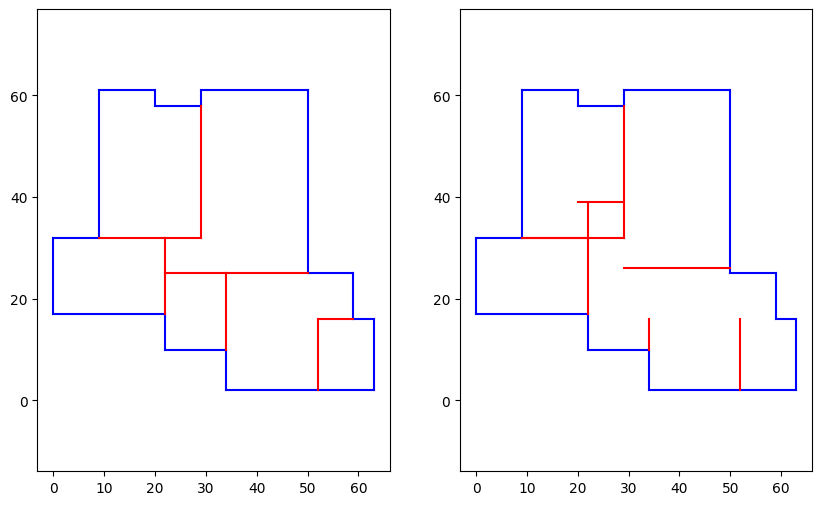

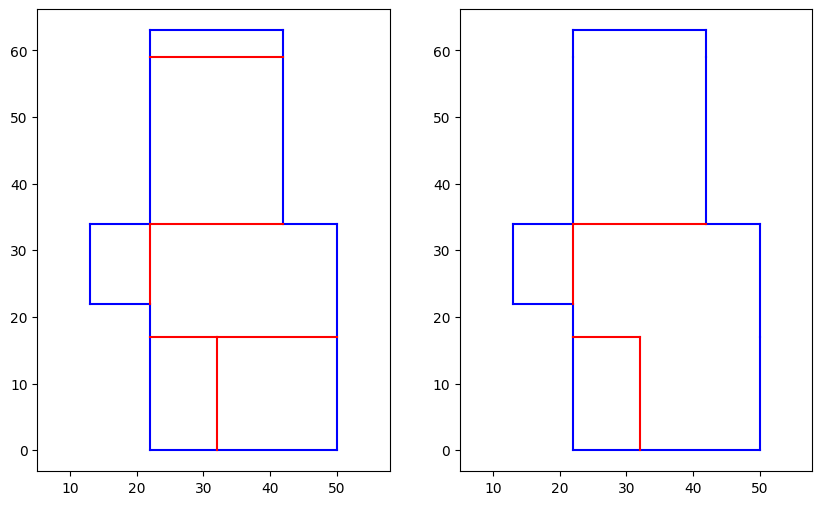

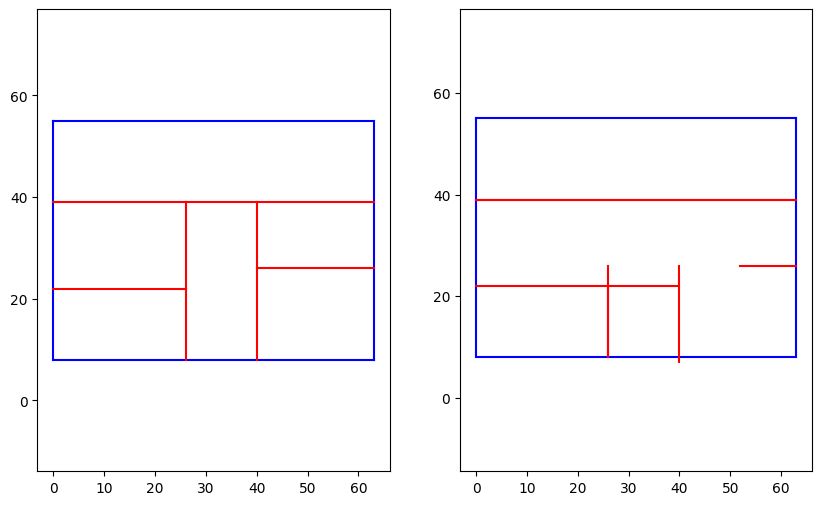

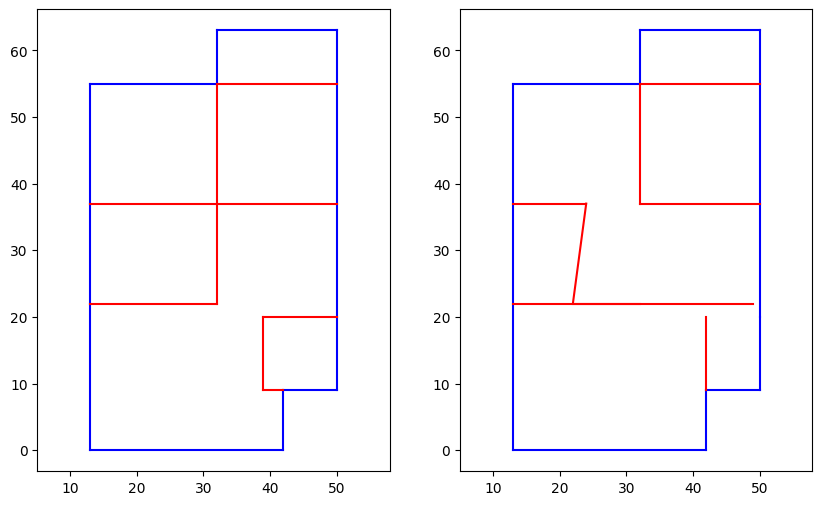

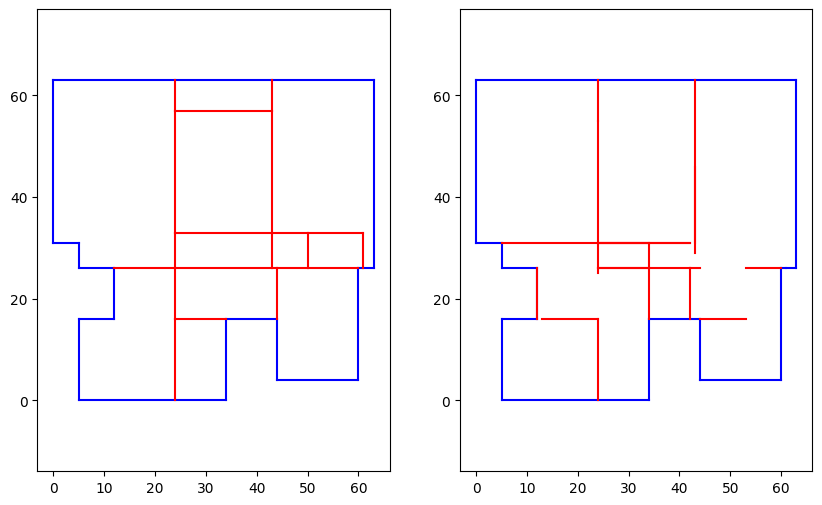

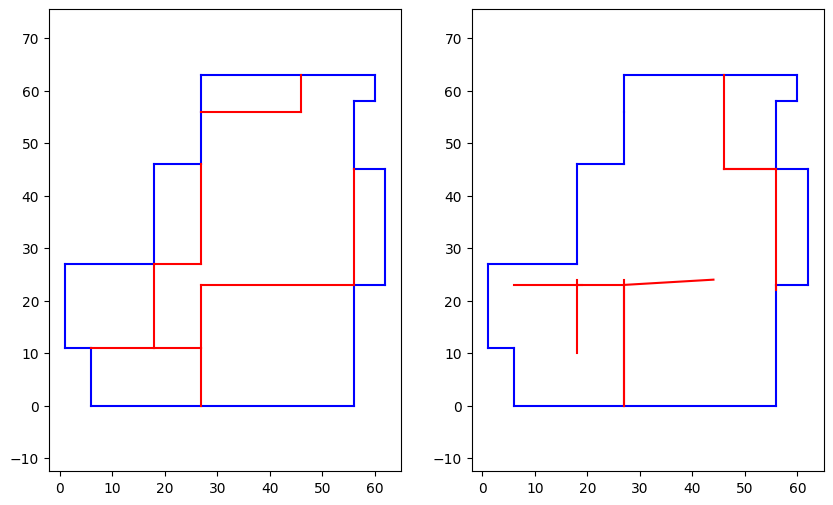

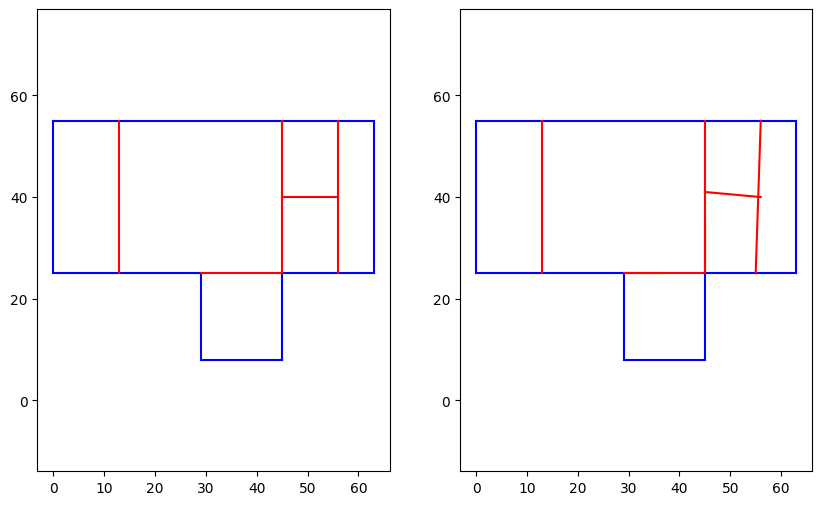

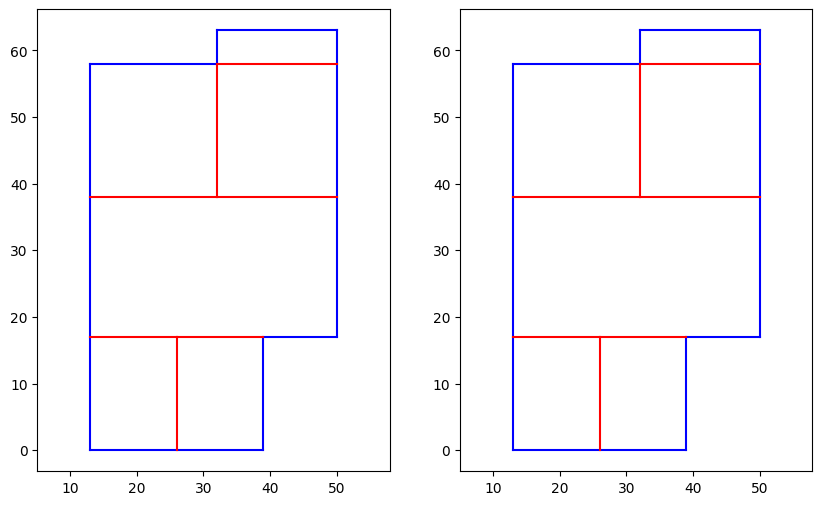

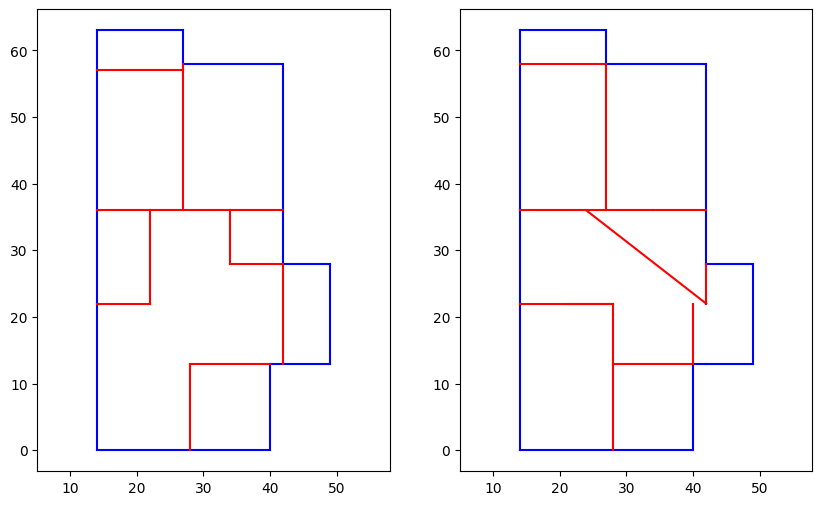

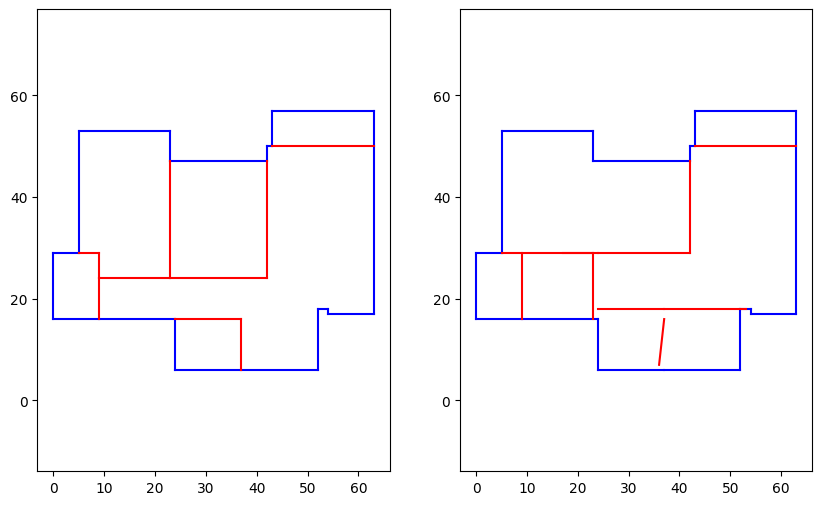

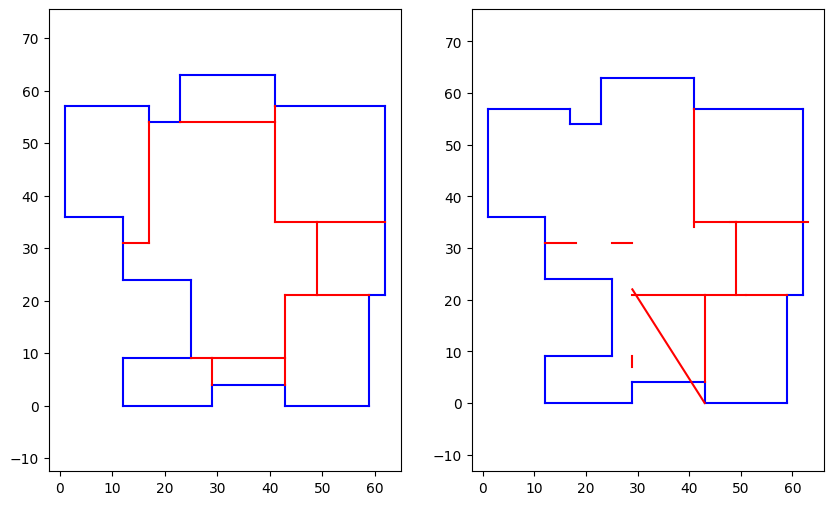

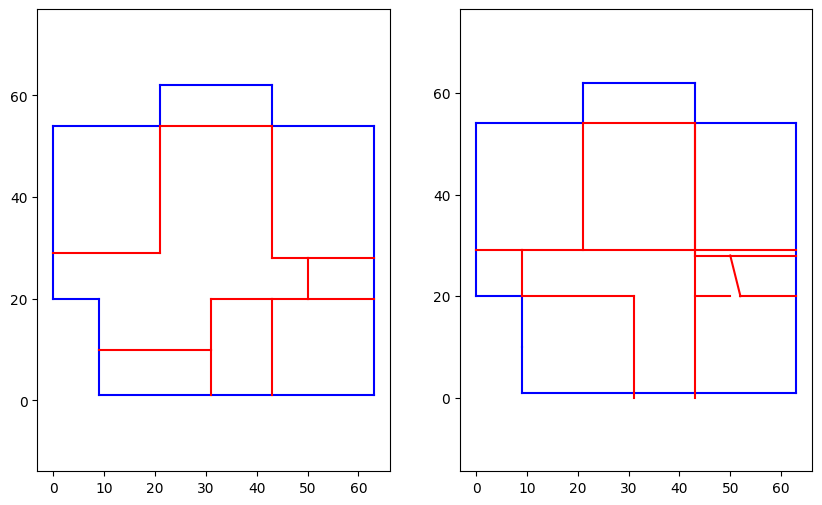

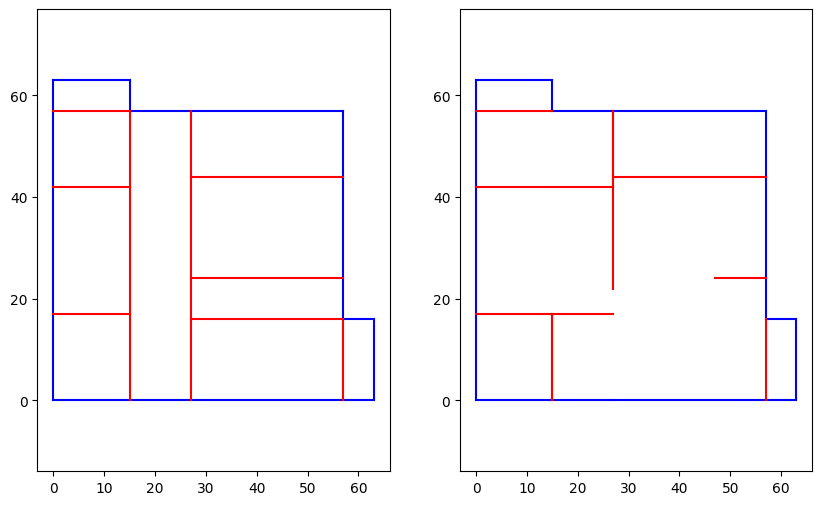

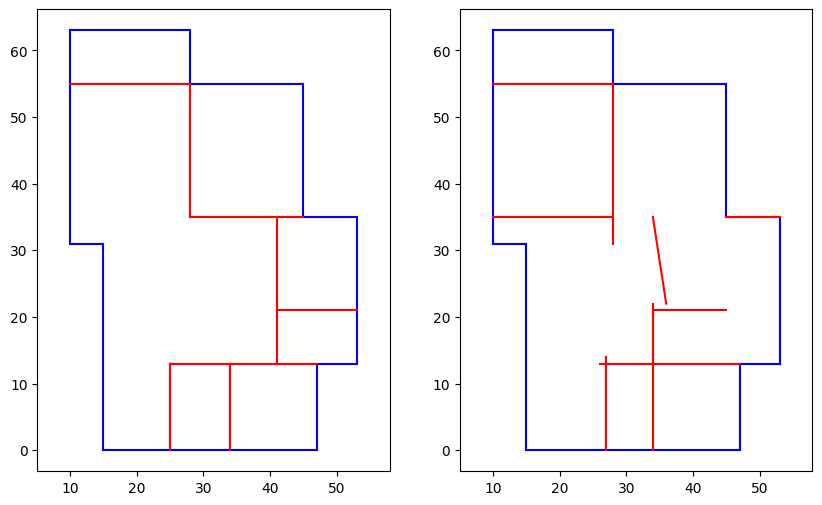

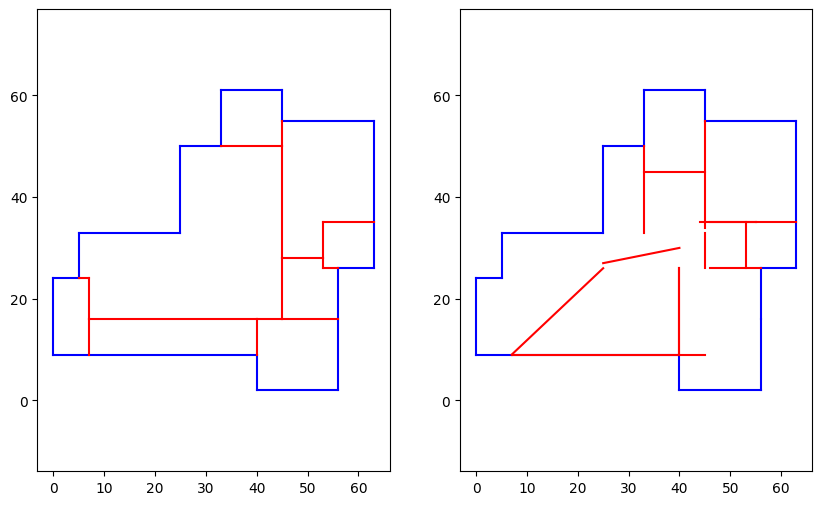

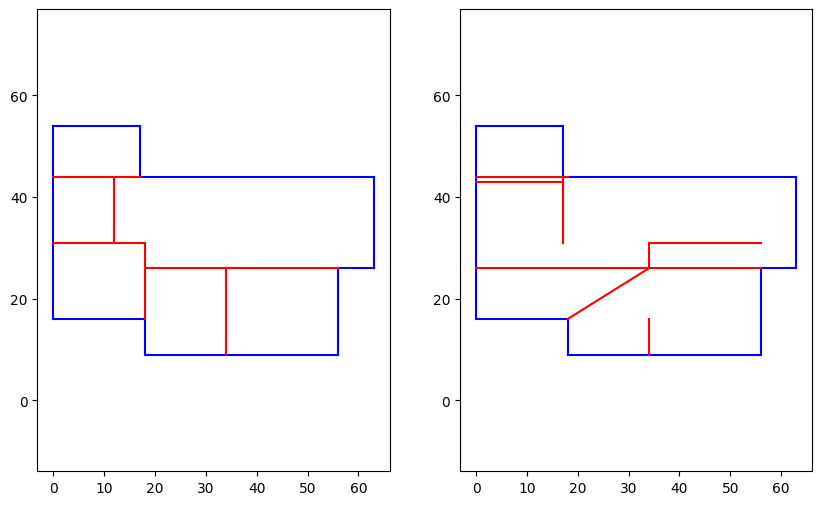

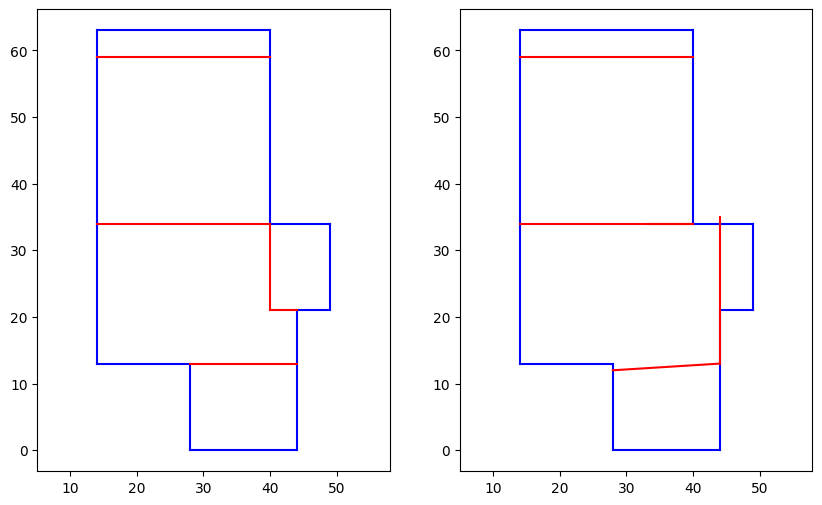

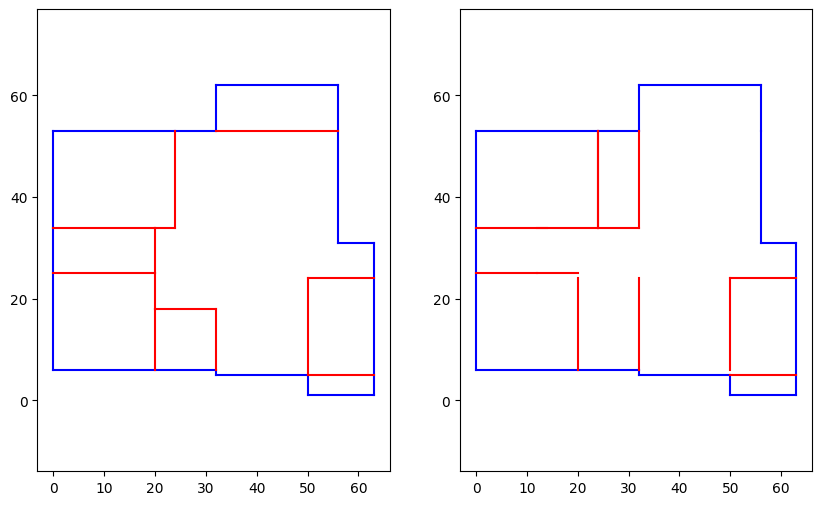

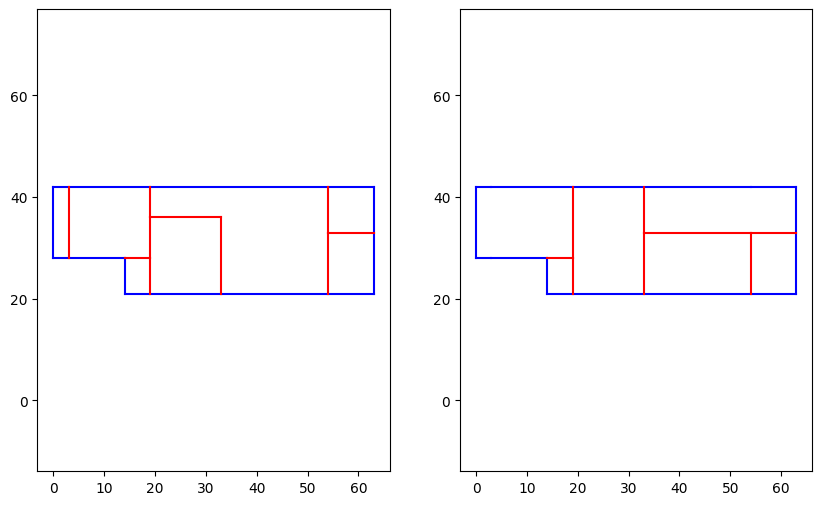

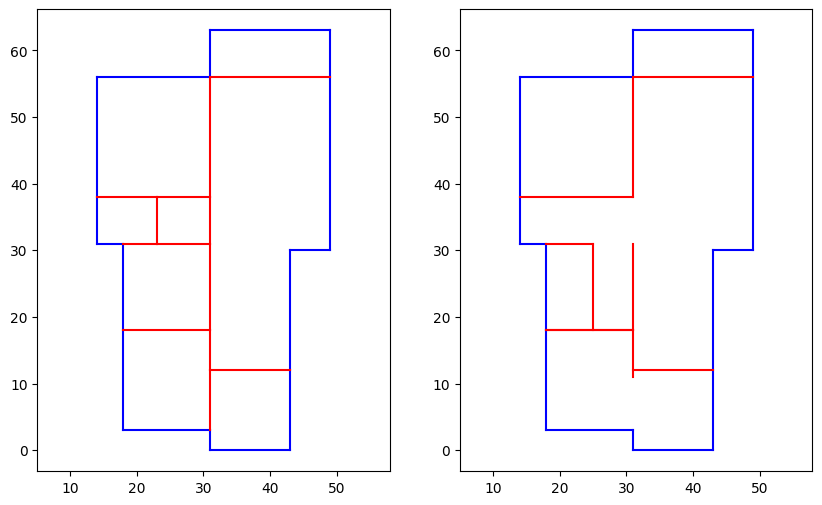

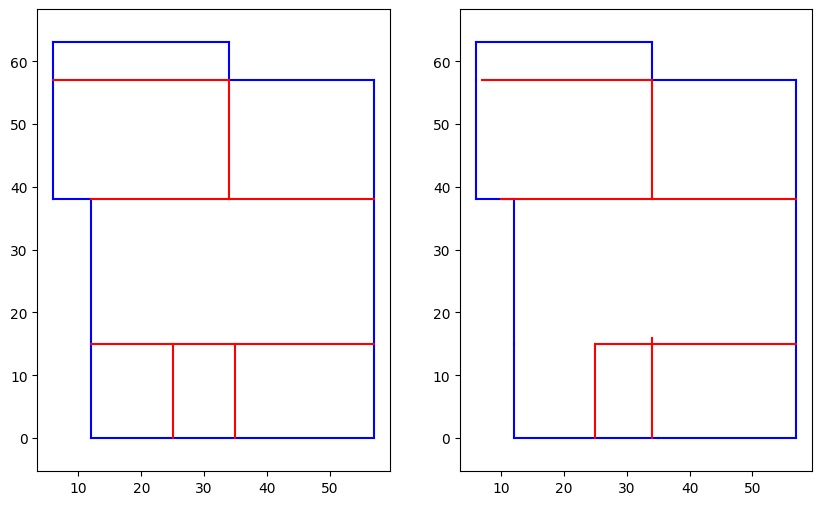

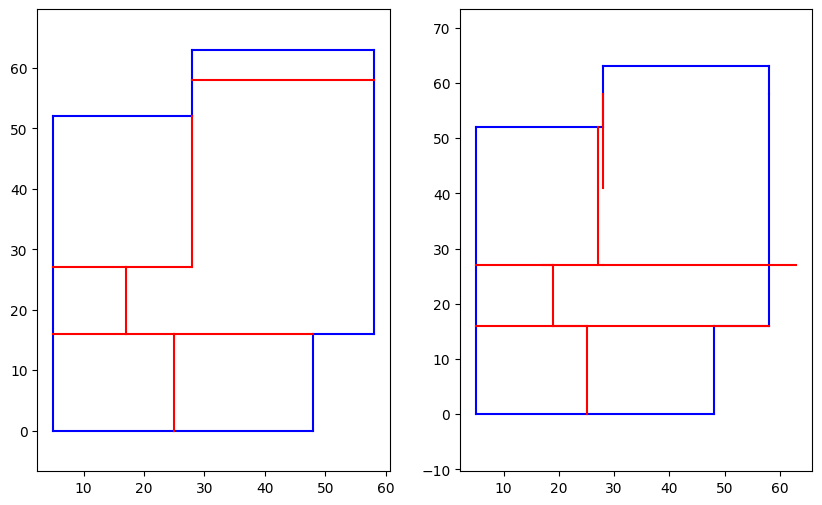

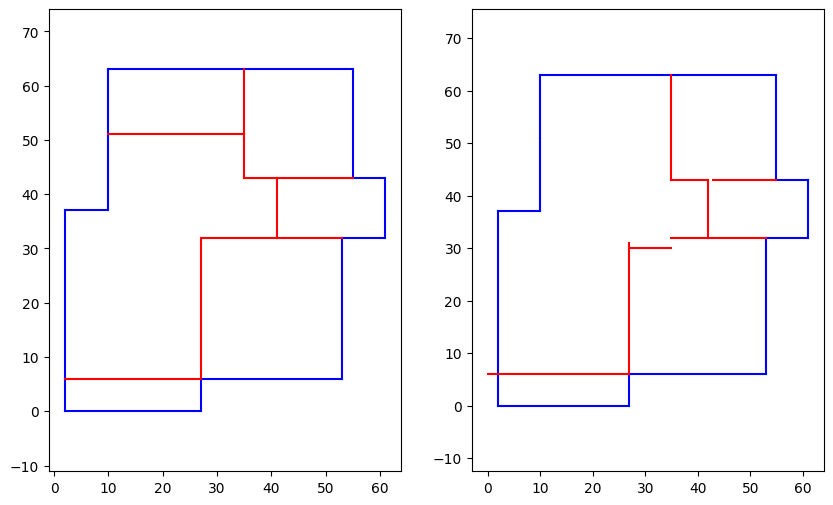

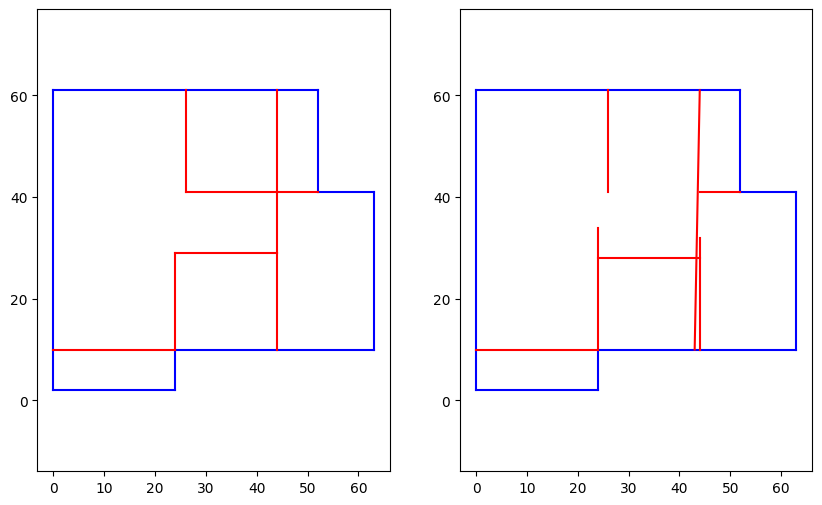

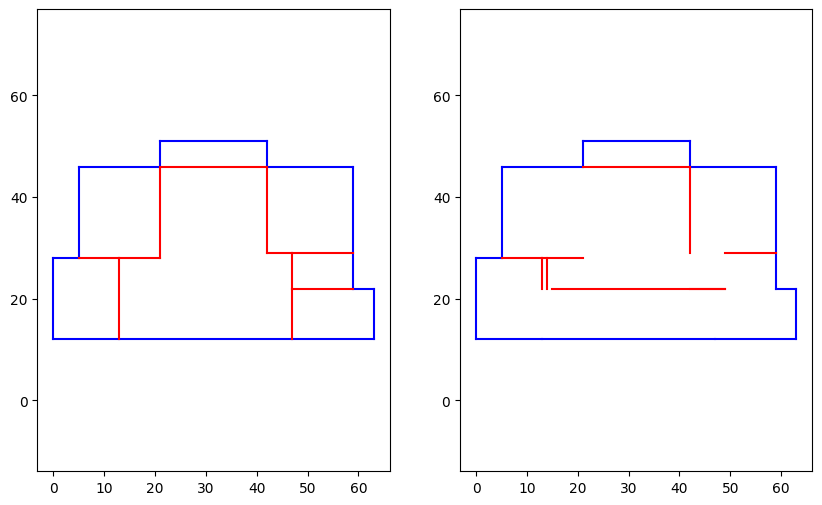

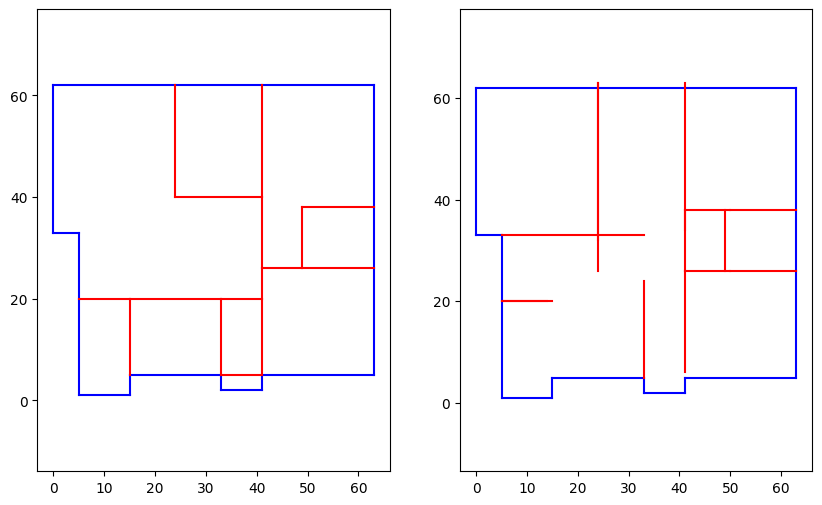

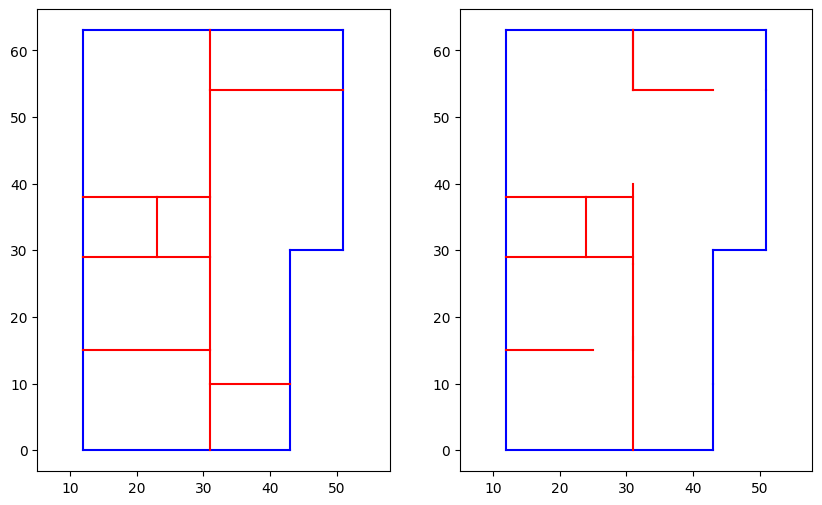

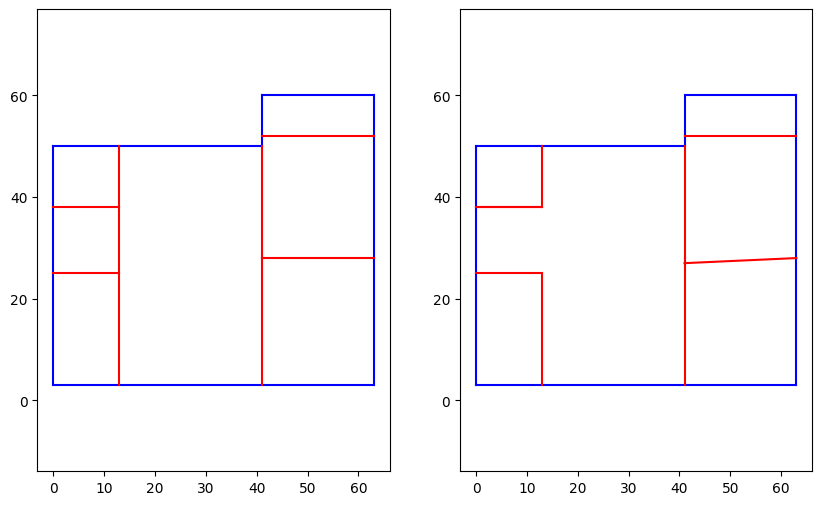

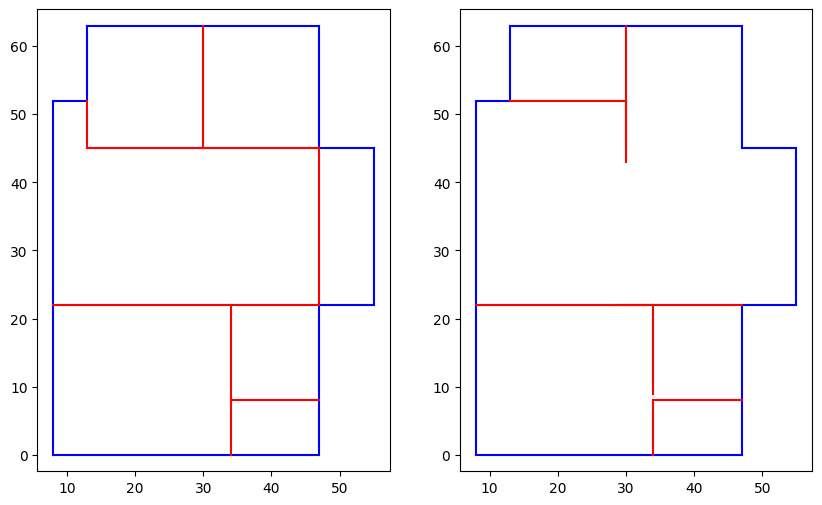

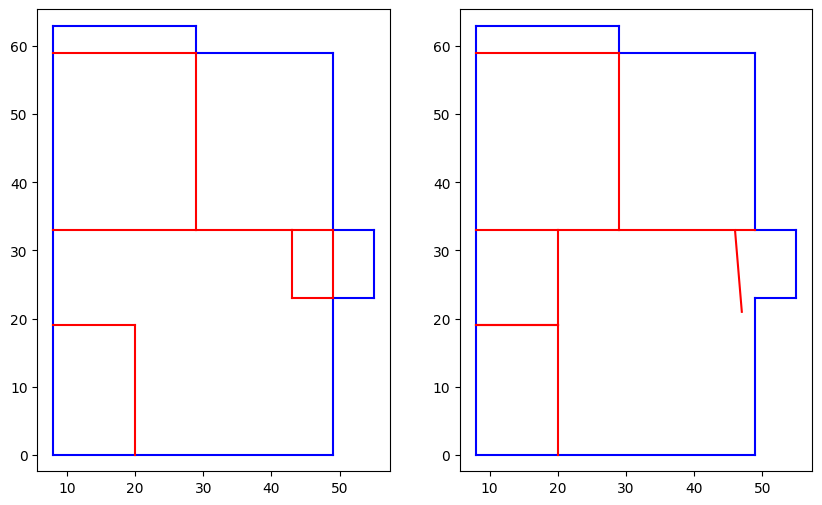

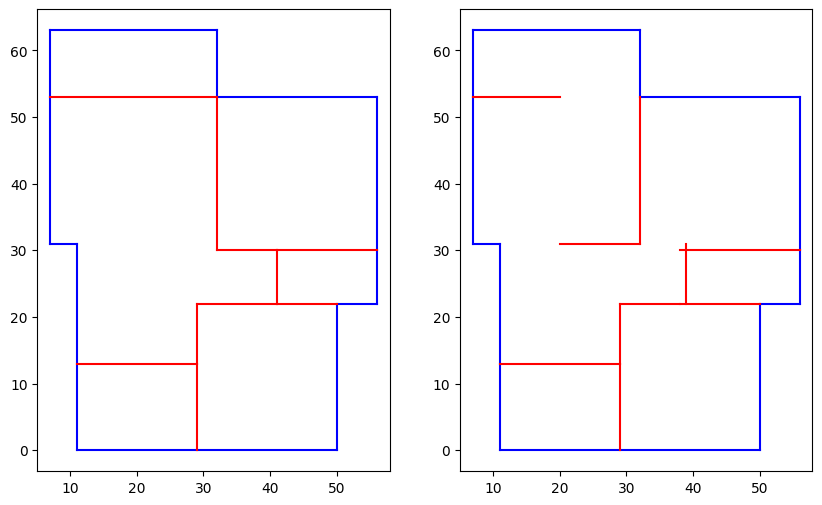

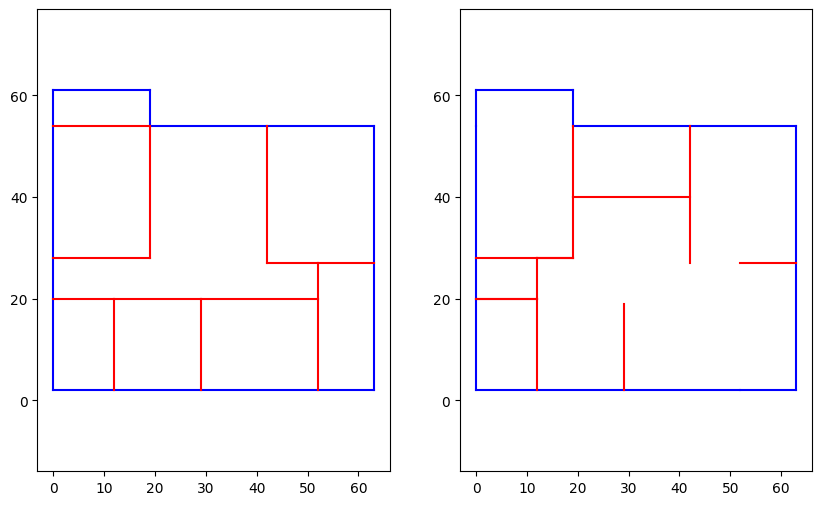

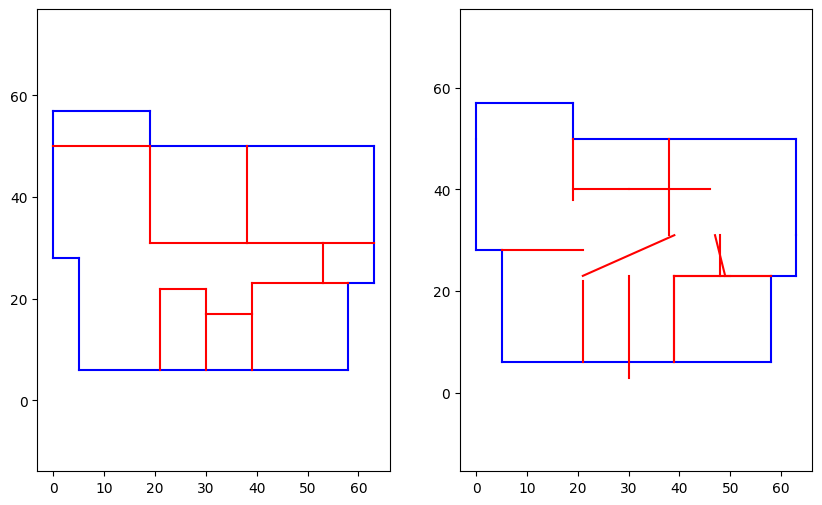

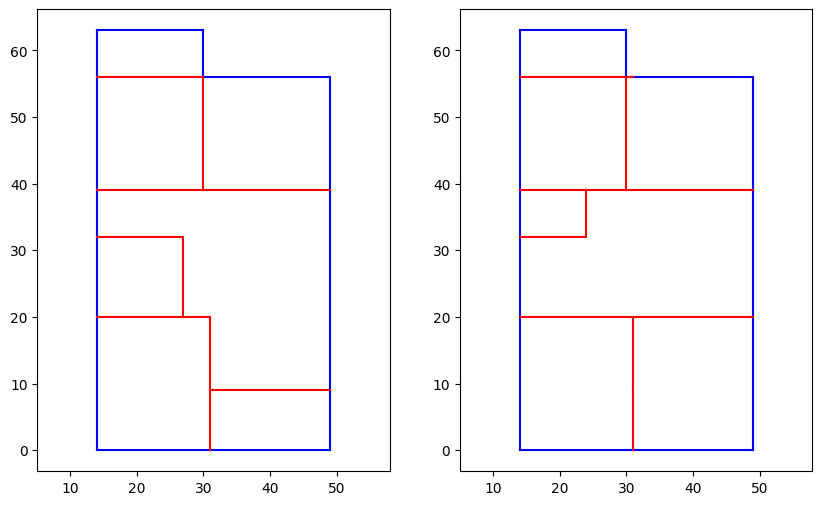

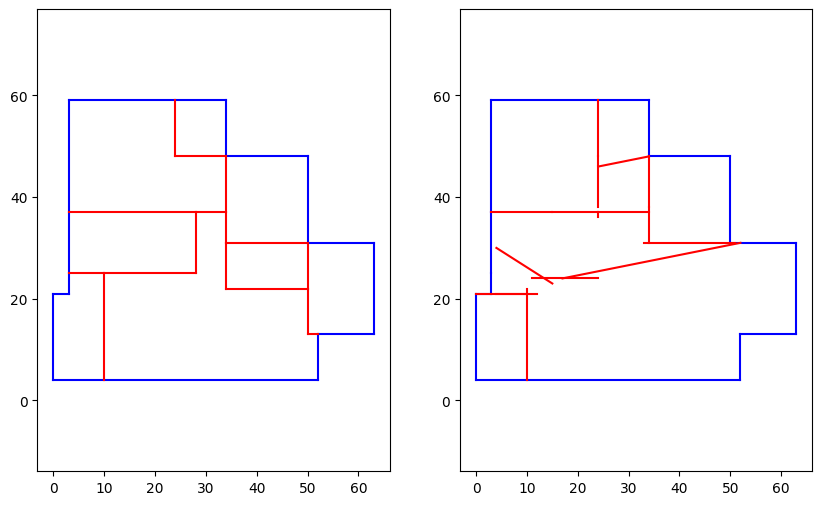

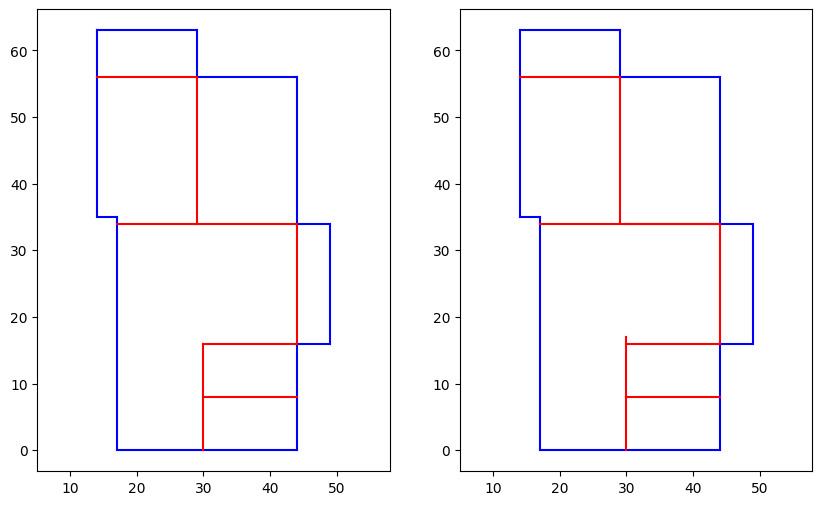

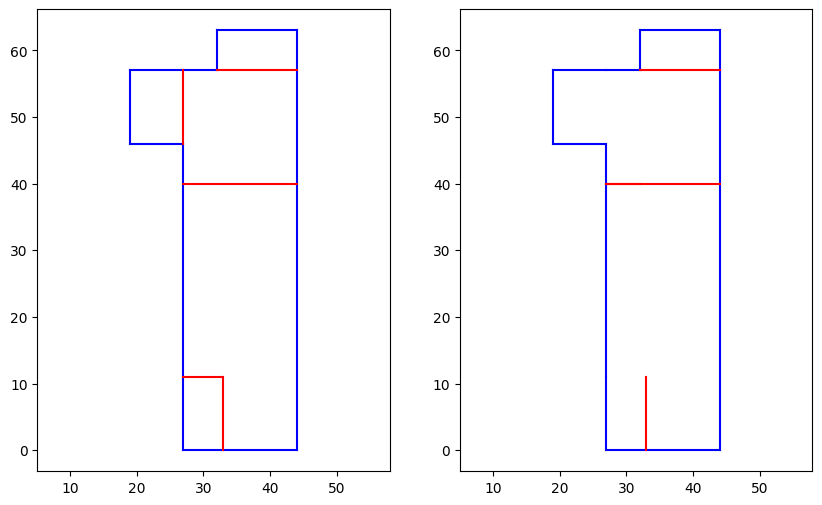

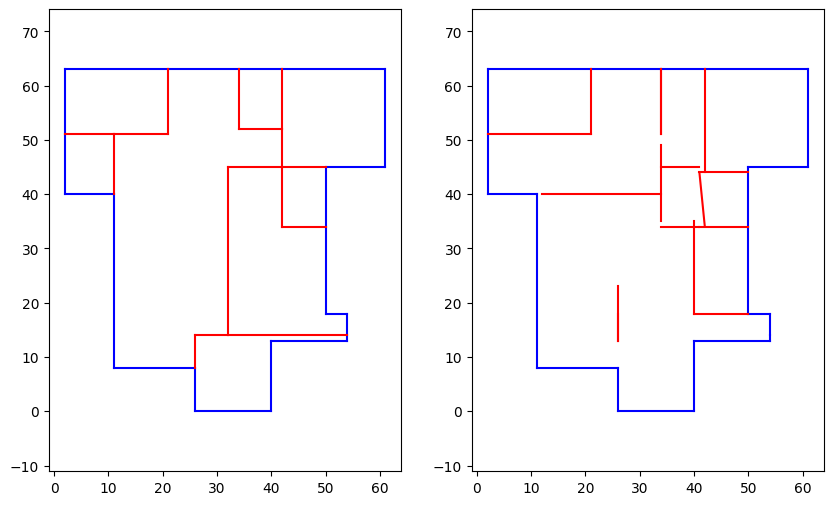

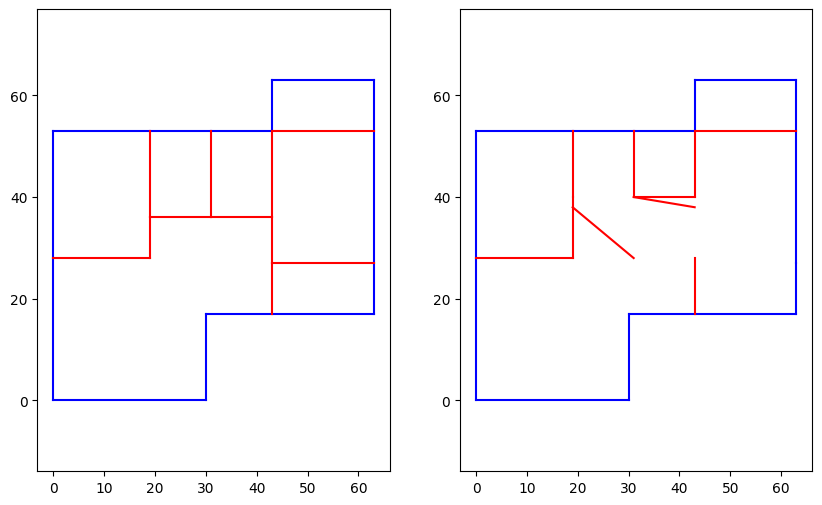

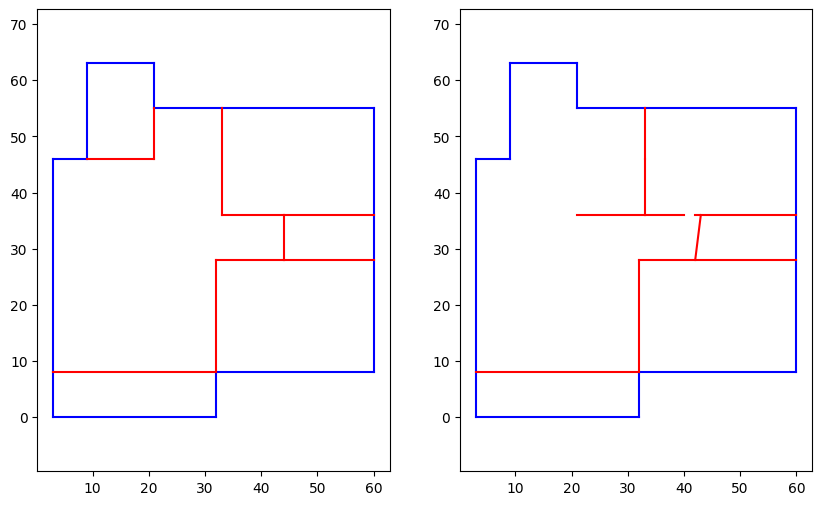

In [45]:
import pylab as plt
# 画图
for _ in range(100):
    plt.figure(figsize=(10, 6))

    plt.subplot(1, 2, 1)
    for i in np.array(boundary[_]):
        plt.plot(i.T[0], i.T[1], 'b')

    for i in np.array(box[_]):
        plt.plot(i.T[0], i.T[1], 'r')
    plt.axis('equal')

    plt.subplot(1, 2, 2)
    for i in np.array(boundary[_]):
        plt.plot(i.T[0], i.T[1], 'b')

    for i in np.array(box_[_]):
        plt.plot(i.T[0], i.T[1], 'r')

    plt.axis('equal')
    #plt.show()
    plt.savefig(f'test/{_}.png')